In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 13.	구별로 학원수 비교 : 서울 대치동이나 목동에 사교육이 발달되었다는 가설을 뒷받침할 수 있는 분석
## ① 서울시 교육(상권업종대분류명 이용) 데이터를 df_academy 변수에 할당하고 확인


In [176]:
df['상권업종대분류명'].unique()

array(['부동산', '음식', '시설관리·임대', '예술·스포츠', '소매', '과학·기술', '수리·개인', '보건의료',
       '숙박', '교육'], dtype=object)

In [177]:
df_academy = df[(df['상권업종대분류명']=='교육')&(df['시도명']=='서울특별시')]
df_academy.shape

(45080, 17)

In [227]:
df_academy.to_csv(r'C:\ai\downloads\shareData\상가정보\ch13_df_academy.csv', index=False)

In [ ]:
df_academy = pd.read_csv(r'C:\ai\downloads\shareData\상가정보\ch13_df_academy.csv')

## ②	df_academy의 상호명별 빈도수 출력(value_counts() / groupby)

In [179]:
df_academy['상호명'].value_counts()

입시·교과학원          280
업소명없음             47
그외기타교육기관          38
예리엘잉글리쉬           22
한우리독서토론논술         16
                ... 
한국방과후교육연구회         1
에프아이비즈니스아카데미주      1
이디엠글로벌캠퍼스          1
알앤지유나이티드주          1
씨올다앤 주식회사          1
Name: 상호명, Length: 41221, dtype: int64

## ③ df_academy의 상호명별 빈도수 상위 10개 출력

In [180]:
df_academy['상호명'].value_counts().head(10)

입시·교과학원      280
업소명없음         47
그외기타교육기관      38
예리엘잉글리쉬       22
한우리독서토론논술     16
개인과외          16
음악학원          15
모던필라테스        14
아메리카요가        11
용인대태권도        11
Name: 상호명, dtype: int64

## ④ df_academy의 시군구명별 빈도수 출력 (학원이 가장 많은 구부터 출력)

In [185]:
df_academy['시군구명'].value_counts()

강남구     6218
서초구     3816
송파구     3137
마포구     2619
양천구     2516
강서구     2275
강동구     2046
노원구     2016
영등포구    1815
성북구     1667
은평구     1561
관악구     1554
광진구     1387
동작구     1386
서대문구    1338
구로구     1310
동대문구    1272
성동구     1183
종로구     1058
중랑구      970
도봉구      899
용산구      871
금천구      828
강북구      762
중구       576
Name: 시군구명, dtype: int64

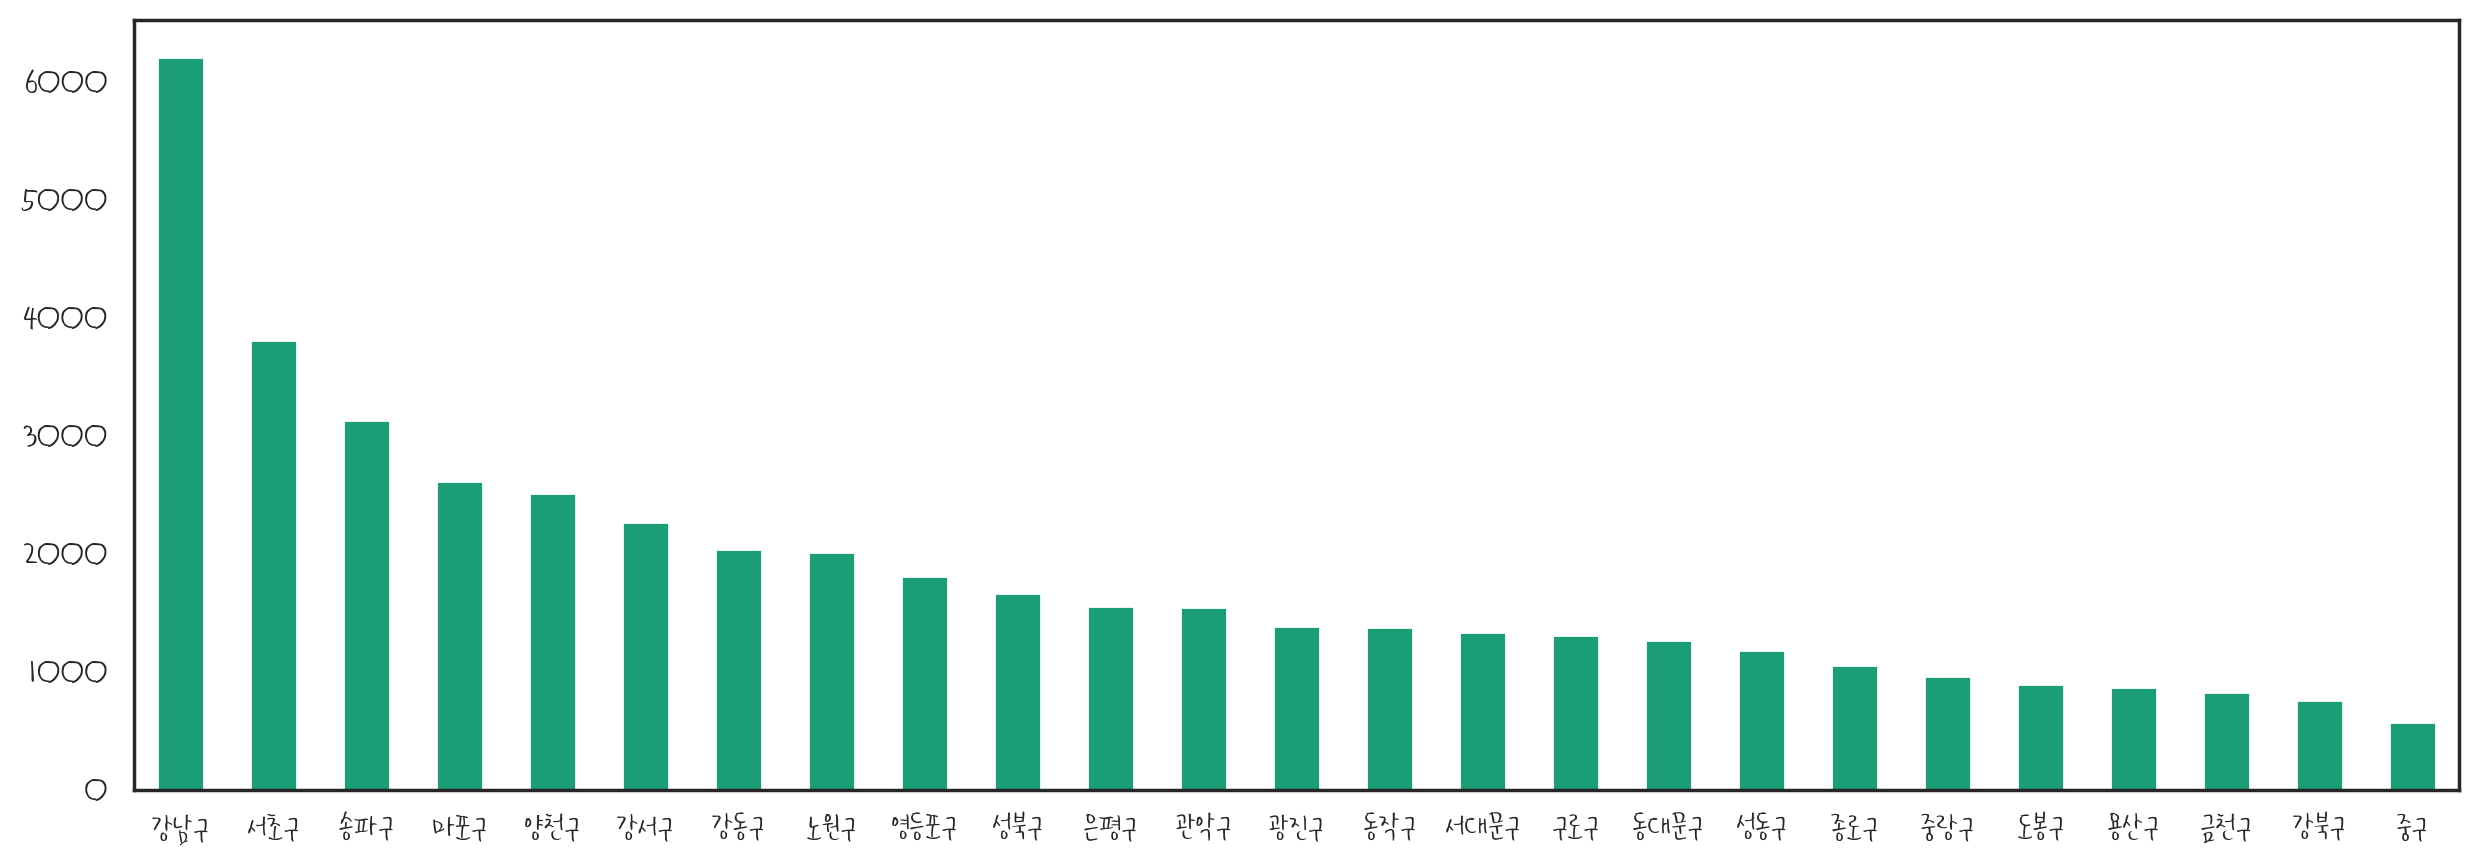

In [187]:
df_academy['시군구명'].value_counts().plot(kind='bar', rot=0)
plt.show()

<Axes: xlabel='시군구명', ylabel='count'>

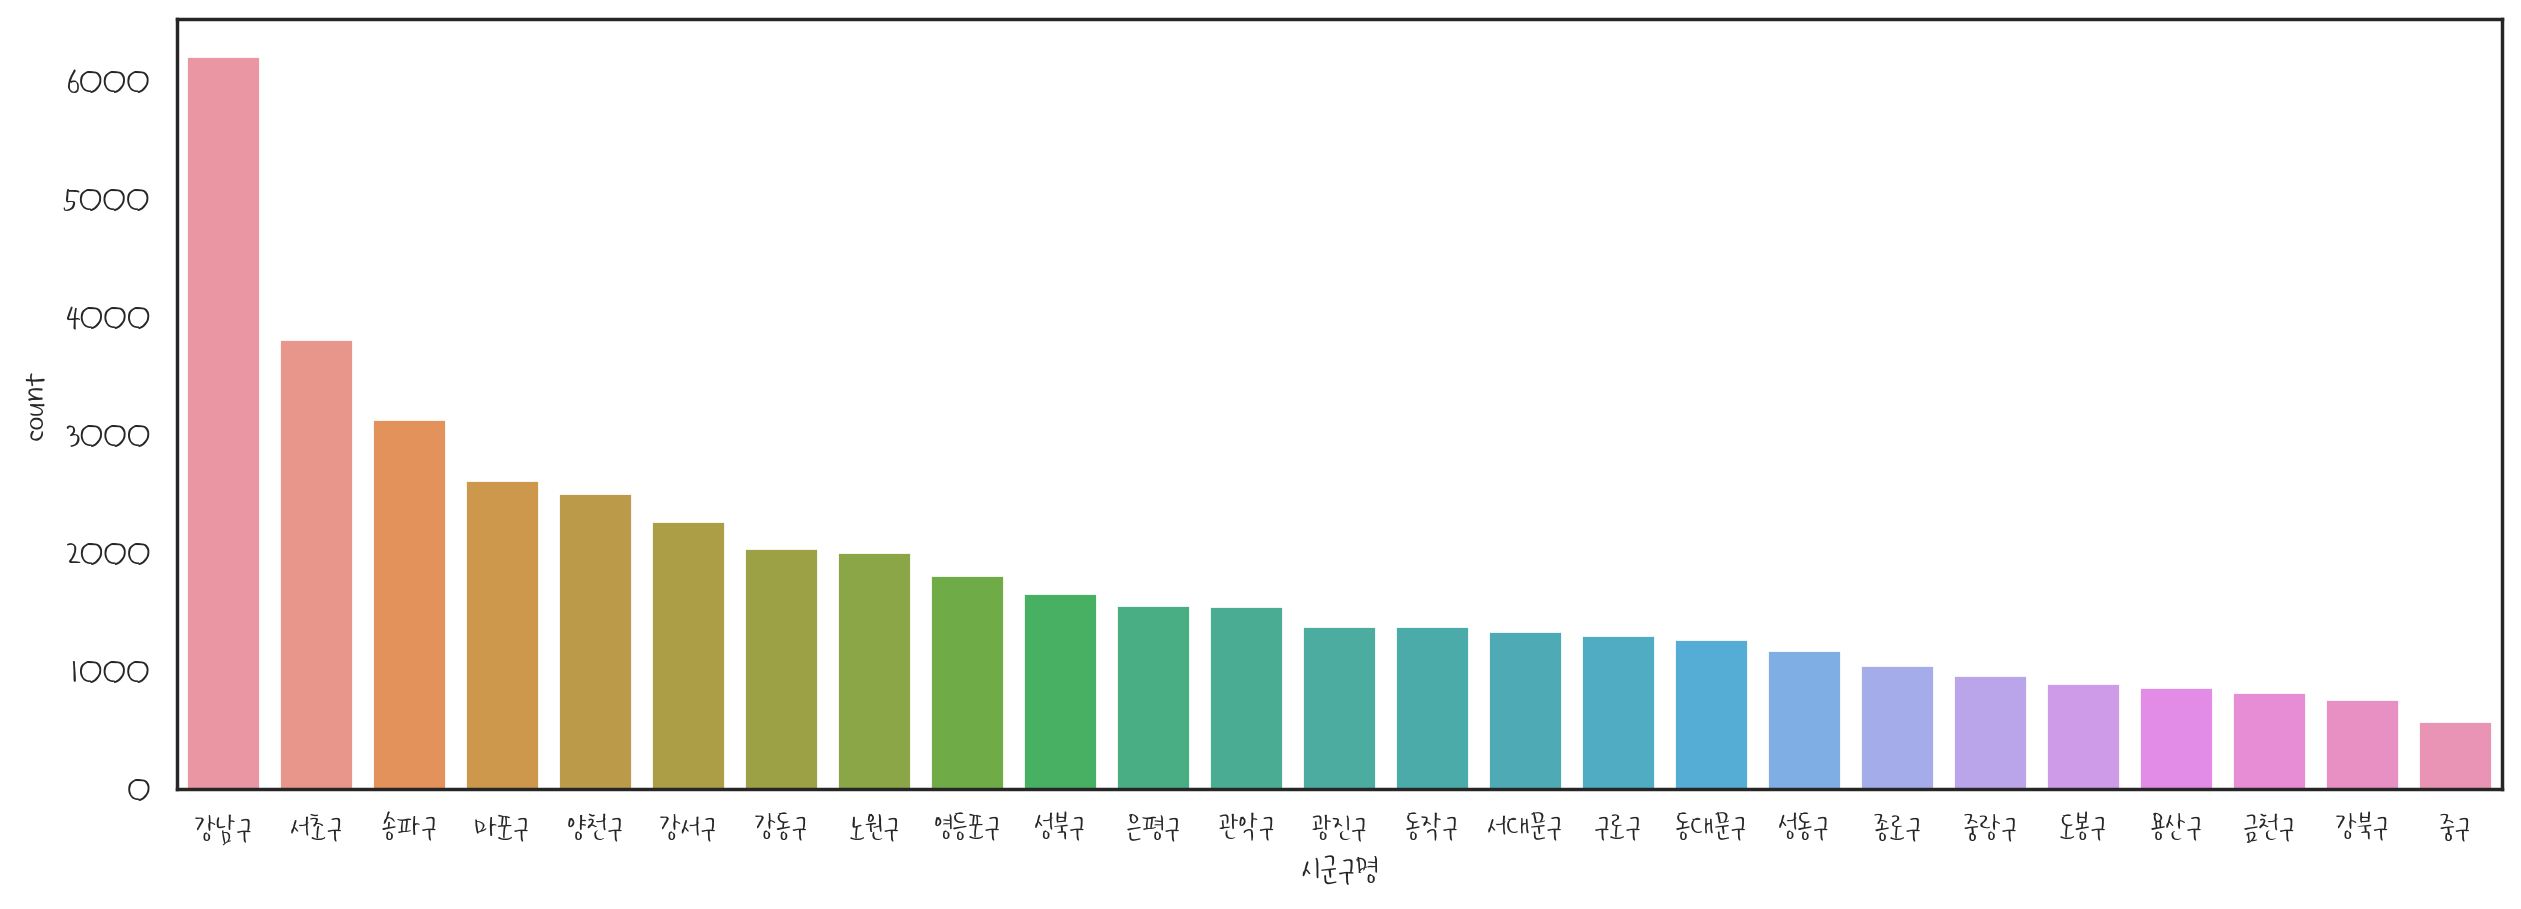

In [189]:
sns.countplot(data=df_academy, x='시군구명', order=df_academy['시군구명'].value_counts().index)

## ⑤ 어떤 분류의 학원이 많은지 상위 10개의 분류를 academy_count 변수에 할당 후 출력(상권업종소분류명 컬럼 이용)

In [193]:
group = df_academy.groupby(['상권업종중분류명','상권업종소분류명'])

for (medium, sub), val in group:
    print(medium, '-', sub)

교육 지원 - 교육컨설팅업
교육 지원 - 기타 교육지원 서비스업
기타 교육 - 그 외 기타 교육기관
기타 교육 - 기타 기술/직업 훈련학원
기타 교육 - 기타 예술/스포츠 교육기관
기타 교육 - 레크리에이션 교육기관
기타 교육 - 미술학원
기타 교육 - 사회교육시설
기타 교육 - 외국어학원
기타 교육 - 요가/필라테스 학원
기타 교육 - 운전학원
기타 교육 - 음악학원
기타 교육 - 전문자격/고시학원
기타 교육 - 직원 훈련기관
기타 교육 - 청소년 수련시설
기타 교육 - 컴퓨터 학원
기타 교육 - 태권도/무술학원
일반 교육 - 입시·교과학원


In [217]:
academy_count = df_academy['상권업종소분류명'].value_counts().head(10)

In [218]:
academy_count.to_frame()

,상권업종소분류명
입시·교과학원,17123
요가/필라테스 학원,4955
음악학원,3907
기타 기술/직업 훈련학원,2890
기타 교육지원 서비스업,2688
미술학원,2512
태권도/무술학원,2227
그 외 기타 교육기관,1944
교육컨설팅업,1784
외국어학원,1262


## ⑥ 상권업종소분류명별 빈도수가 1000 이상인 데이터를  academy_count_1000 변수에 할당

In [223]:
academy_counts = df_academy['상권업종소분류명'].value_counts()
academy_count_1000 = academy_counts[academy_counts>1000]

In [224]:
academy_count_1000

입시·교과학원           17123
요가/필라테스 학원         4955
음악학원               3907
기타 기술/직업 훈련학원      2890
기타 교육지원 서비스업       2688
미술학원               2512
태권도/무술학원           2227
그 외 기타 교육기관        1944
교육컨설팅업             1784
외국어학원              1262
기타 예술/스포츠 교육기관     1200
Name: 상권업종소분류명, dtype: int64

In [226]:
top1000 = df_academy[df_academy['상권업종소분류명'].isin(academy_count_1000.index)]
top1000.shape

(42492, 17)

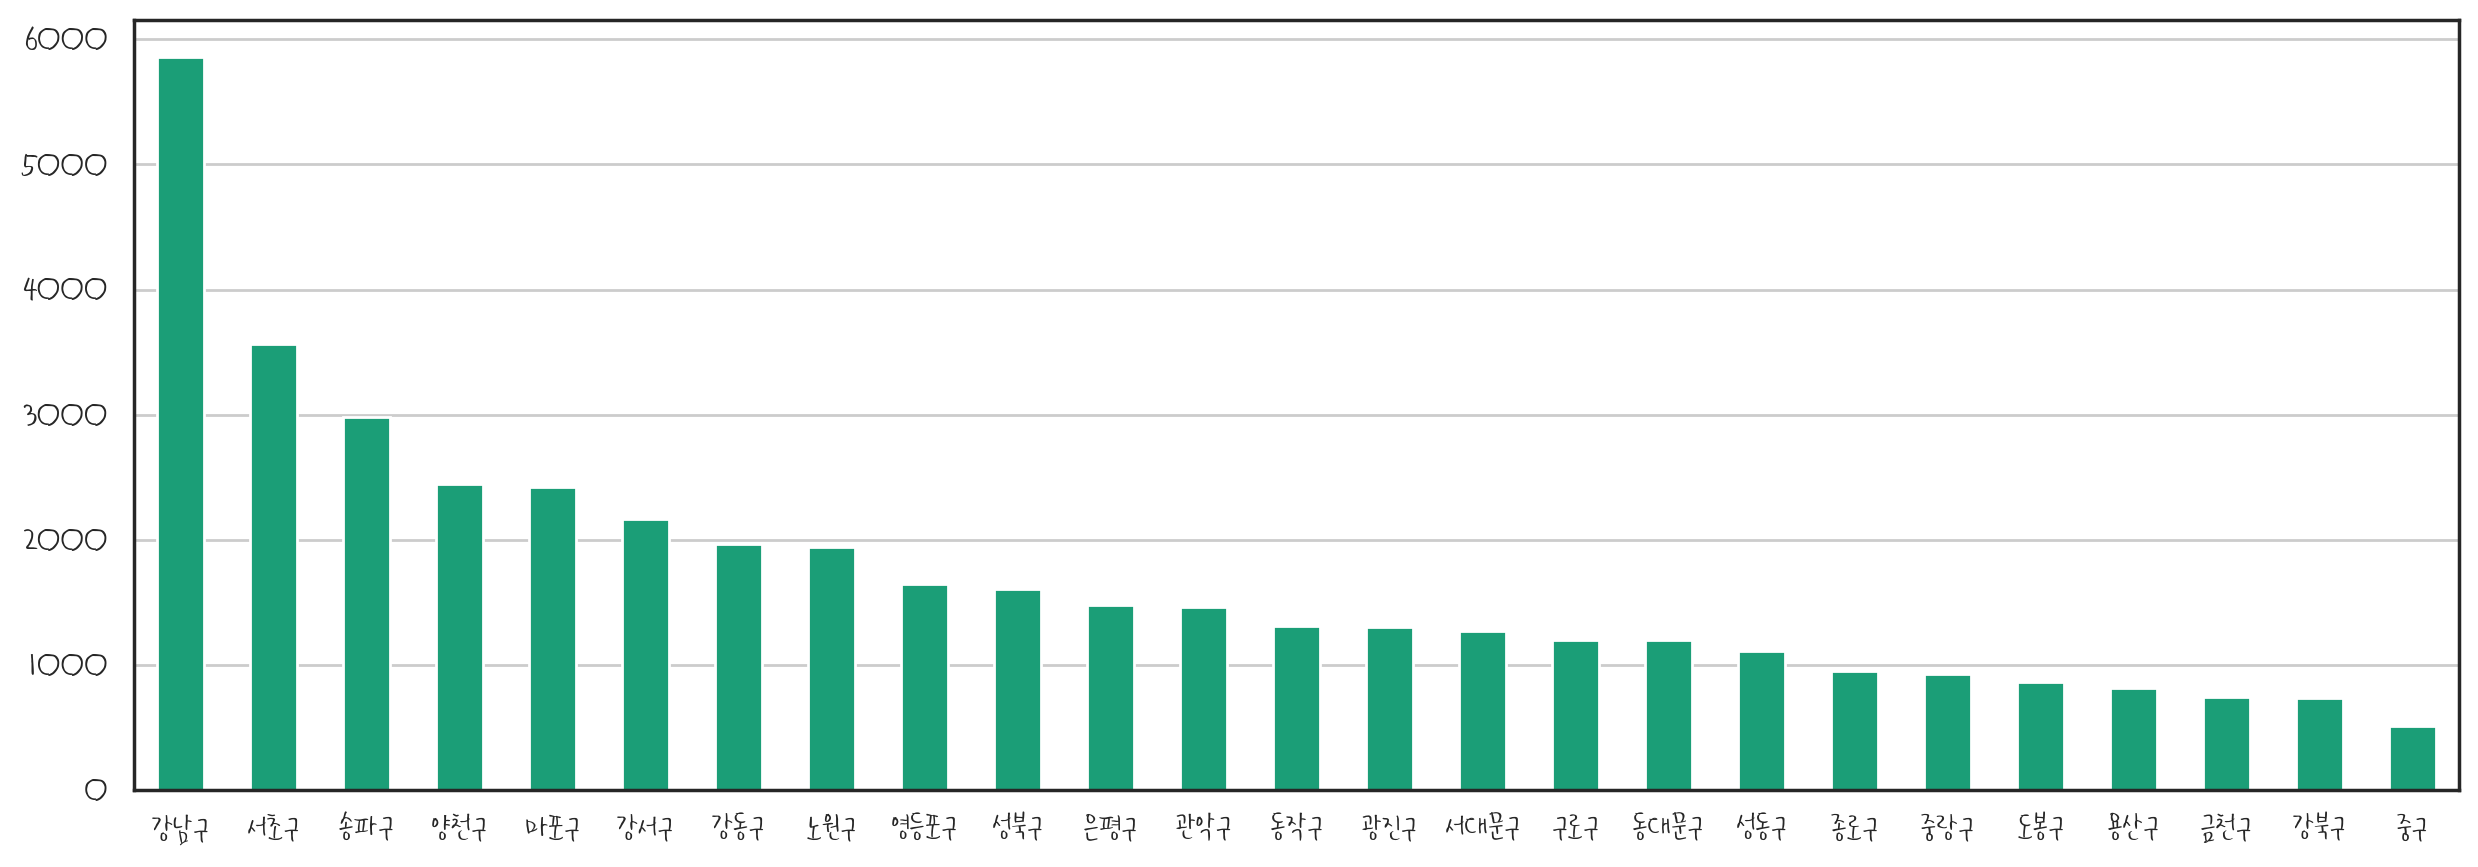

In [230]:
top1000['시군구명'].value_counts().plot(kind='bar', rot=0)
plt.grid(axis='y')

## ⑦ 시군구명, 상권업종소분류명별 상호명 빈도수를 변수에 할당 및 출력

In [241]:
academy_group = df_academy.groupby(['시군구명', '상권업종소분류명'])['상호명'].count()

In [242]:
academy_group

시군구명  상권업종소분류명      
강남구   교육컨설팅업            467
      그 외 기타 교육기관       294
      기타 교육지원 서비스업      622
      기타 기술/직업 훈련학원     319
      기타 예술/스포츠 교육기관    157
                       ... 
중랑구   전문자격/고시학원           3
      직원 훈련기관             7
      청소년 수련시설            1
      컴퓨터 학원              4
      태권도/무술학원           74
Name: 상호명, Length: 445, dtype: int64

## ⑧ 강남구 데이터 시각화(barplot)

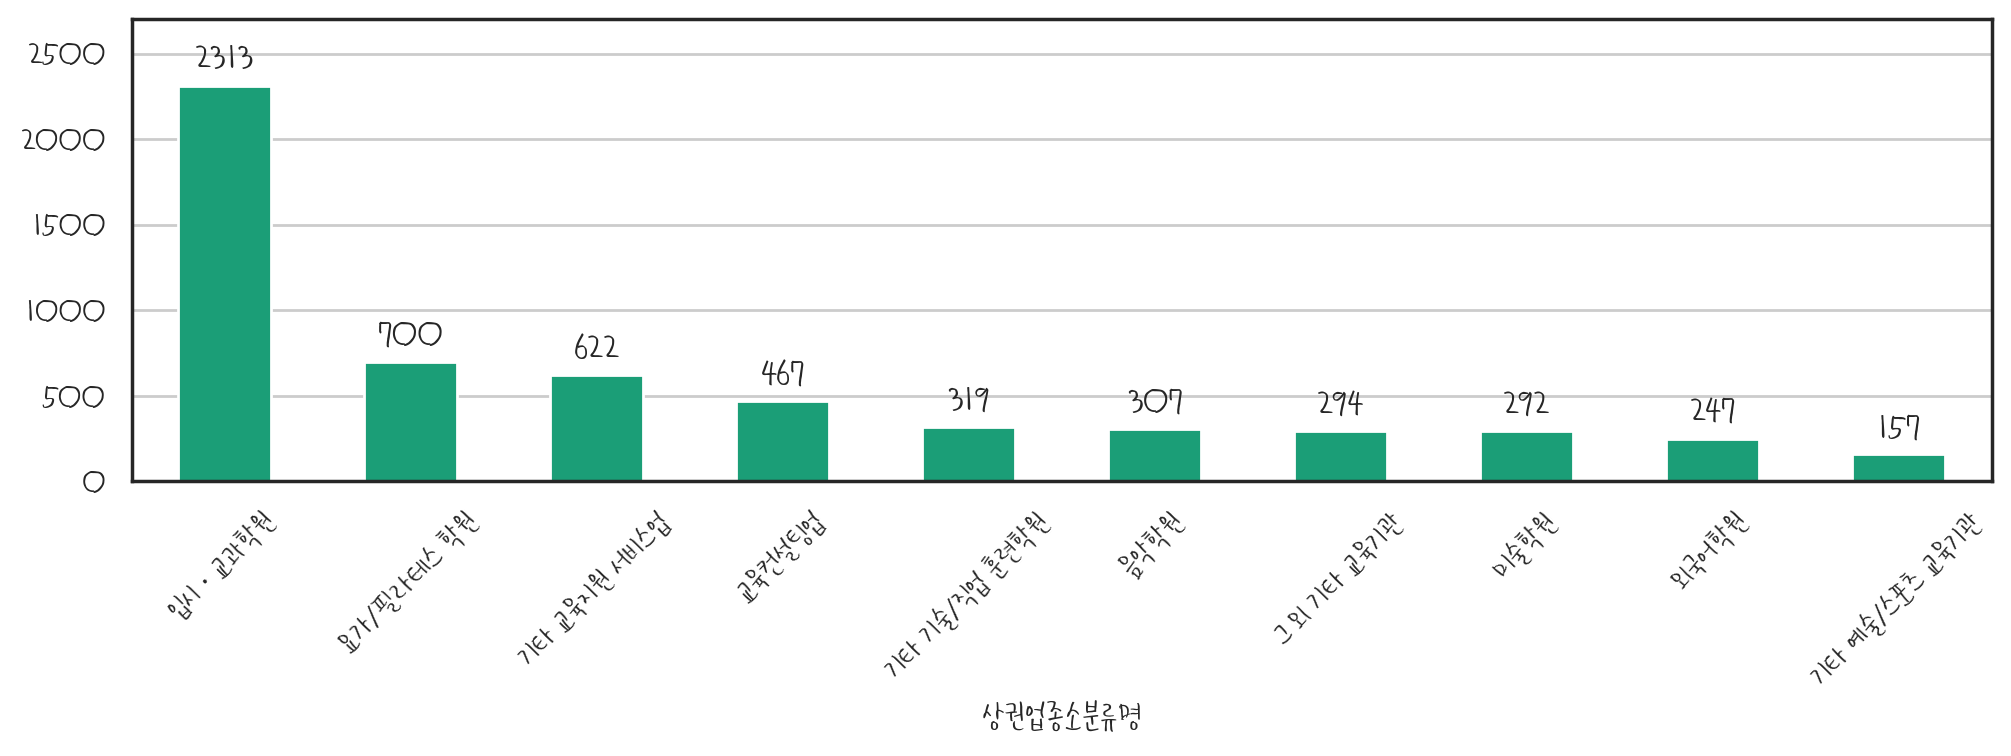

In [249]:
result = academy_group['강남구'].sort_values(ascending=False)
ax = result.head(10).plot(kind='bar', rot = 45)
labels = ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=12)
plt.ylim([0,2700])
plt.grid(axis='y')
plt.show()

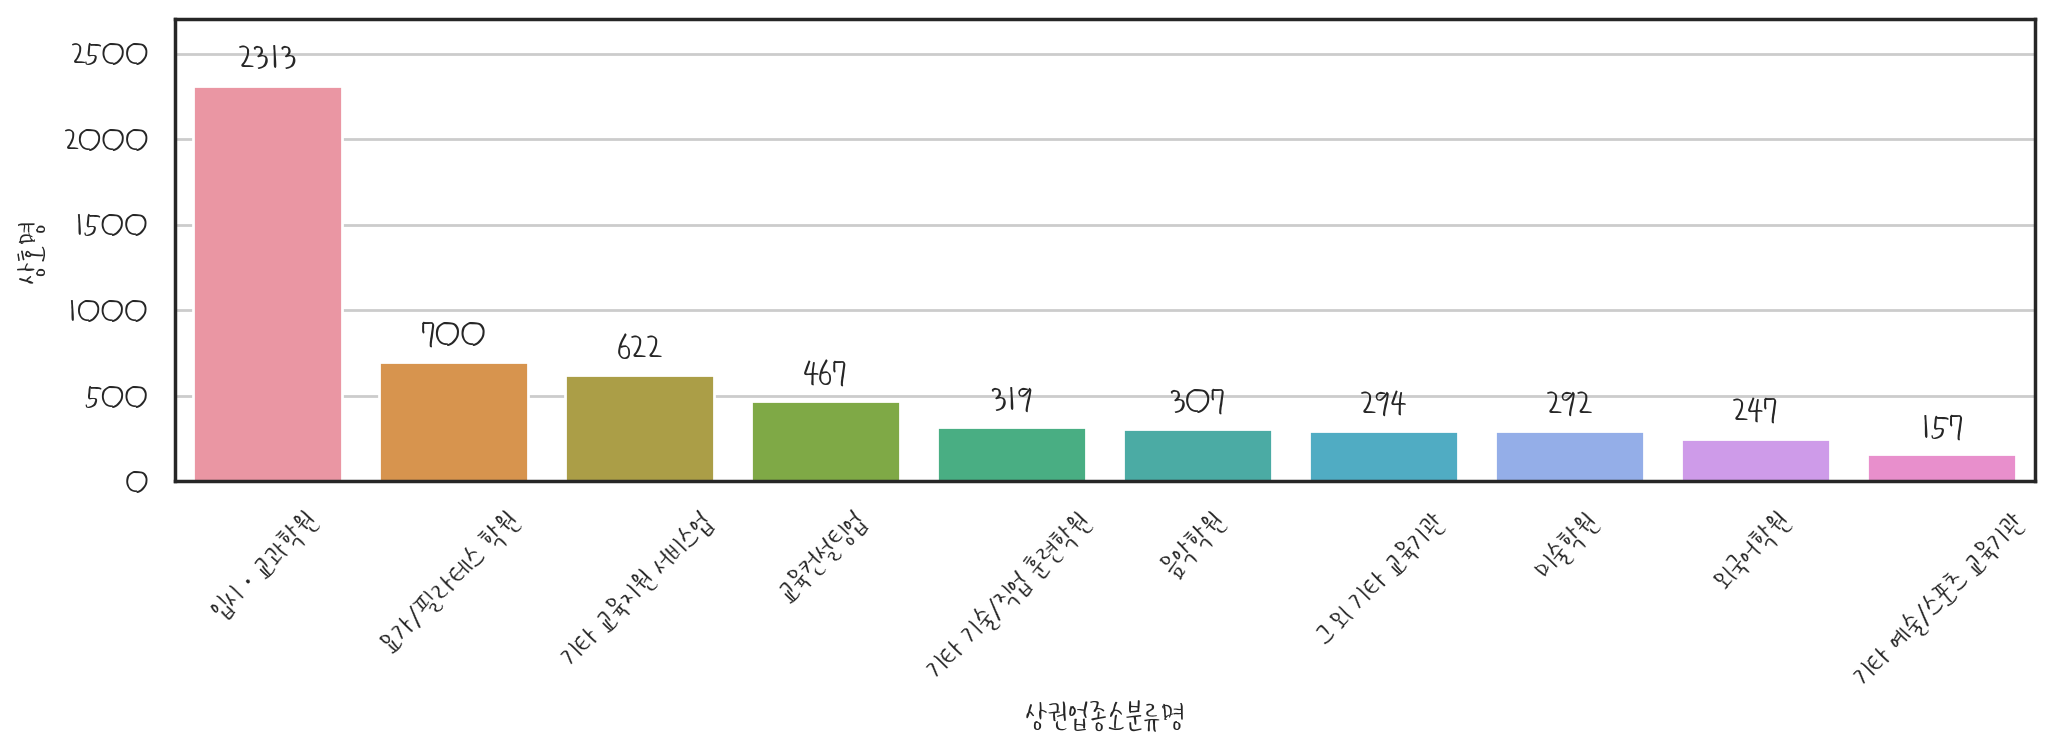

In [252]:
result = academy_group['강남구'].sort_values(ascending=False).head(10)
ax = sns.barplot(x = result.index, y = result)
plt.xticks(rotation=45)
labels = ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=12)
plt.ylim([0,2700])
plt.grid(axis='y')
plt.show()

## ⑨ “법정동명”이 “대치동”과 “목동”인 데이터에서 상권업종소분류명별 빈도수 출력

In [257]:
df_academy.loc[df_academy['법정동명']=='대치동', '상권업종소분류명'].value_counts()[:3]

입시·교과학원    1268
교육컨설팅업      130
미술학원         93
Name: 상권업종소분류명, dtype: int64

In [258]:
df_academy.loc[df_academy['법정동명']=='목동', '상권업종소분류명'].value_counts()[:3]

입시·교과학원       711
음악학원           87
요가/필라테스 학원     83
Name: 상권업종소분류명, dtype: int64

In [263]:
top3 = df_academy.loc[df_academy['법정동명'].isin(['대치동', '목동']), '상권업종소분류명'].value_counts().head(3)
top2 = top3.drop('요가/필라테스 학원')
top2

입시·교과학원    1979
교육컨설팅업      158
Name: 상권업종소분류명, dtype: int64

In [270]:
df_academy_sel = df_academy[df_academy['상권업종소분류명'].isin(top2.index)]

In [274]:
df_academy_sel['법정동명'].value_counts().head(10)

대치동    1398
목동      739
신정동     611
중계동     584
서초동     473
신사동     337
역삼동     336
봉천동     332
상계동     322
명일동     318
Name: 법정동명, dtype: int64

## ⑩상권업종소분류명, 시군구명별 상호명 빈도수를 g 변수에 할당 후 출력

In [288]:
g = df_academy.groupby(['상권업종소분류명', '시군구명'])['상호명'].count()

In [289]:
g

상권업종소분류명  시군구명
교육컨설팅업    강남구     467
          강동구      35
          강북구      20
          강서구      53
          관악구      54
                 ... 
태권도/무술학원  용산구      33
          은평구     101
          종로구      28
          중구       19
          중랑구      74
Name: 상호명, Length: 445, dtype: int64

## ⑪ g 변수 중 상권업종소분류명 “입시·교과학원” 데이터만 시각화 (pandas-plot.bar, pandas-barh, seaborn-barplot)

In [294]:
result = g['입시·교과학원'].sort_values(ascending=False)
result

시군구명
강남구     2313
양천구     1443
서초구     1235
송파구     1221
노원구     1057
강동구      961
강서구      912
성북구      775
마포구      768
은평구      679
동작구      586
관악구      568
서대문구     529
동대문구     527
광진구      499
영등포구     493
구로구      460
도봉구      398
중랑구      370
성동구      366
강북구      286
종로구      198
금천구      196
용산구      190
중구        93
Name: 상호명, dtype: int64

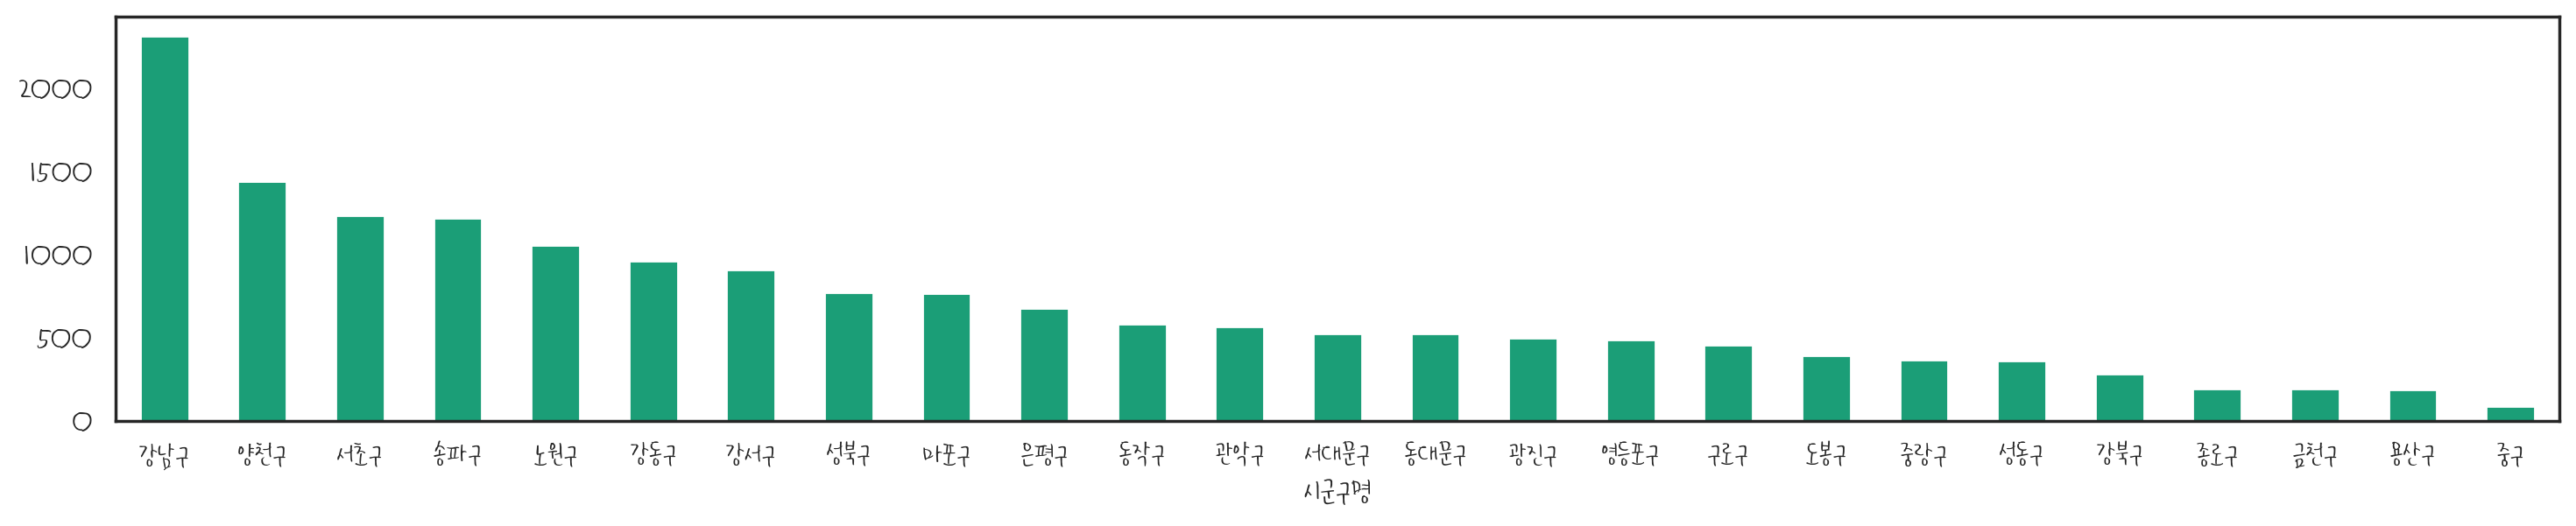

In [295]:
plt.figure(figsize=(18,3))
result.plot(kind='bar', rot=0)
plt.show()

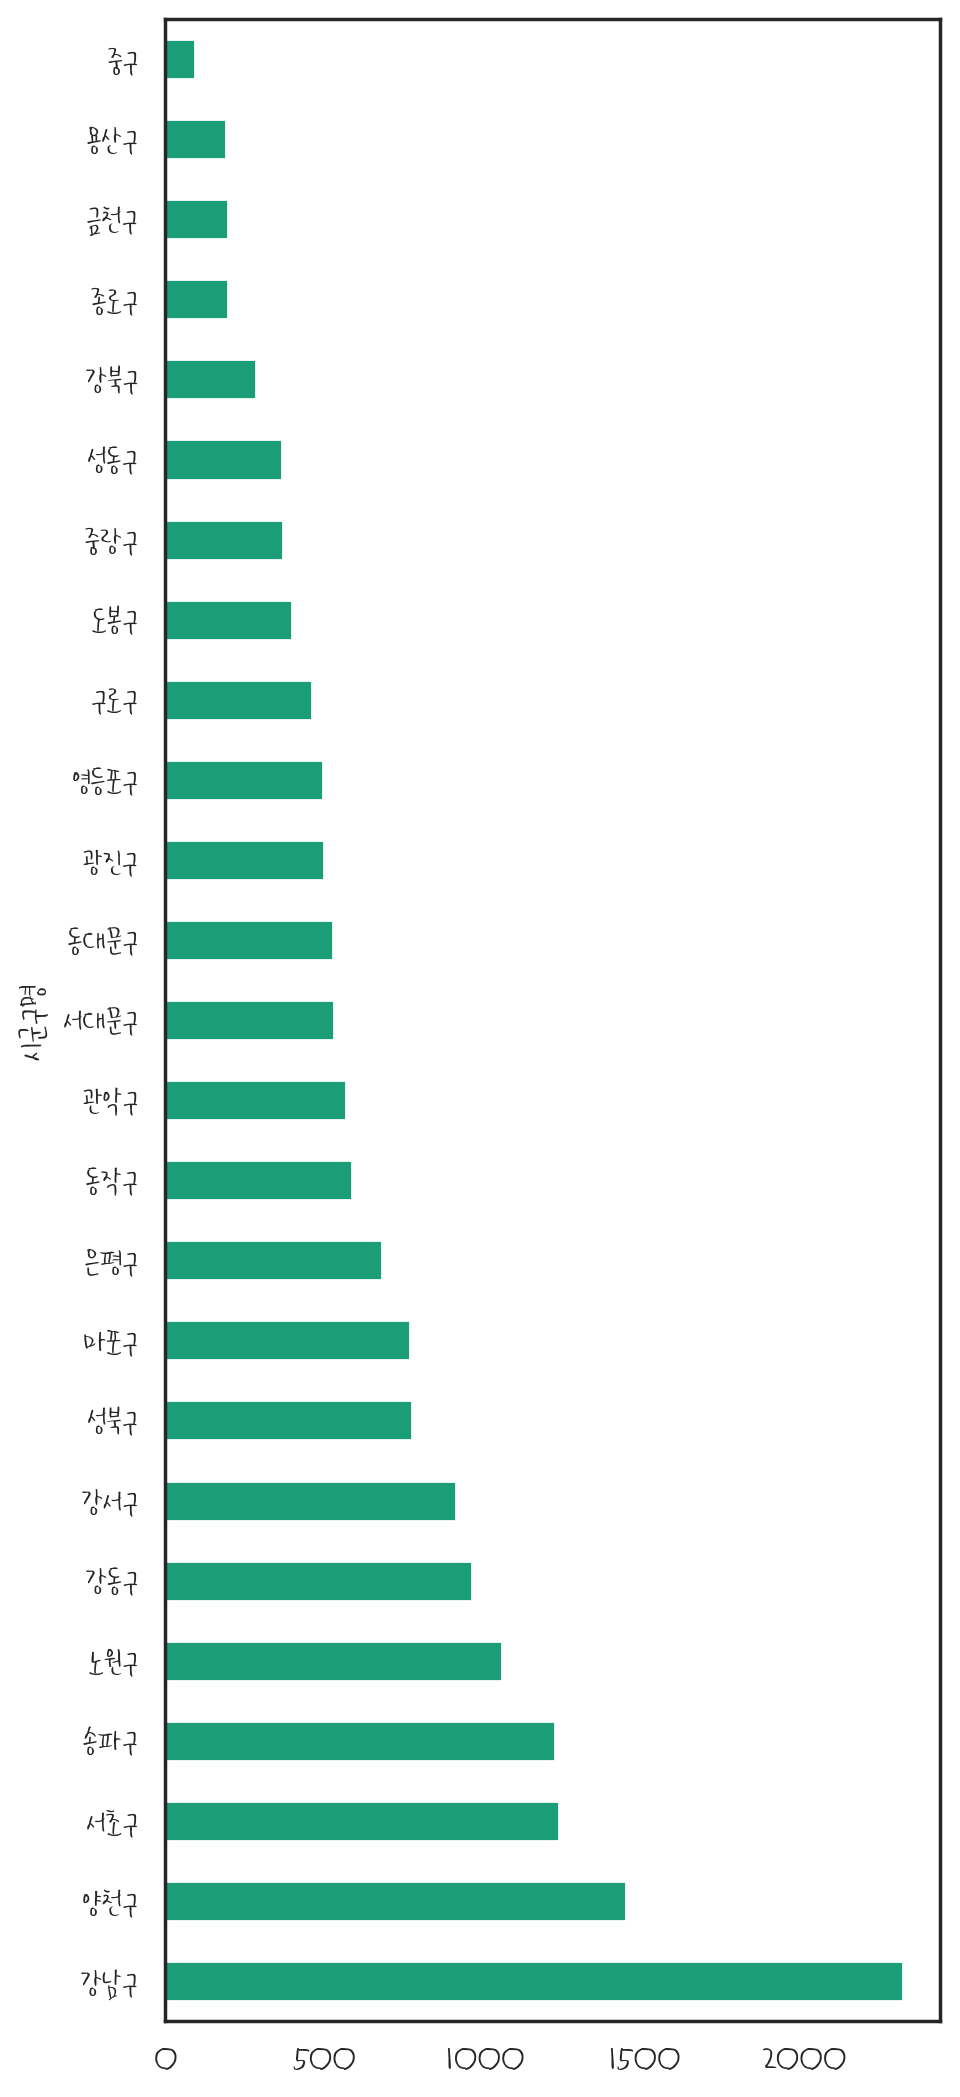

In [296]:
plt.figure(figsize=(5,13))
result.plot(kind='barh', rot=0)
plt.show()

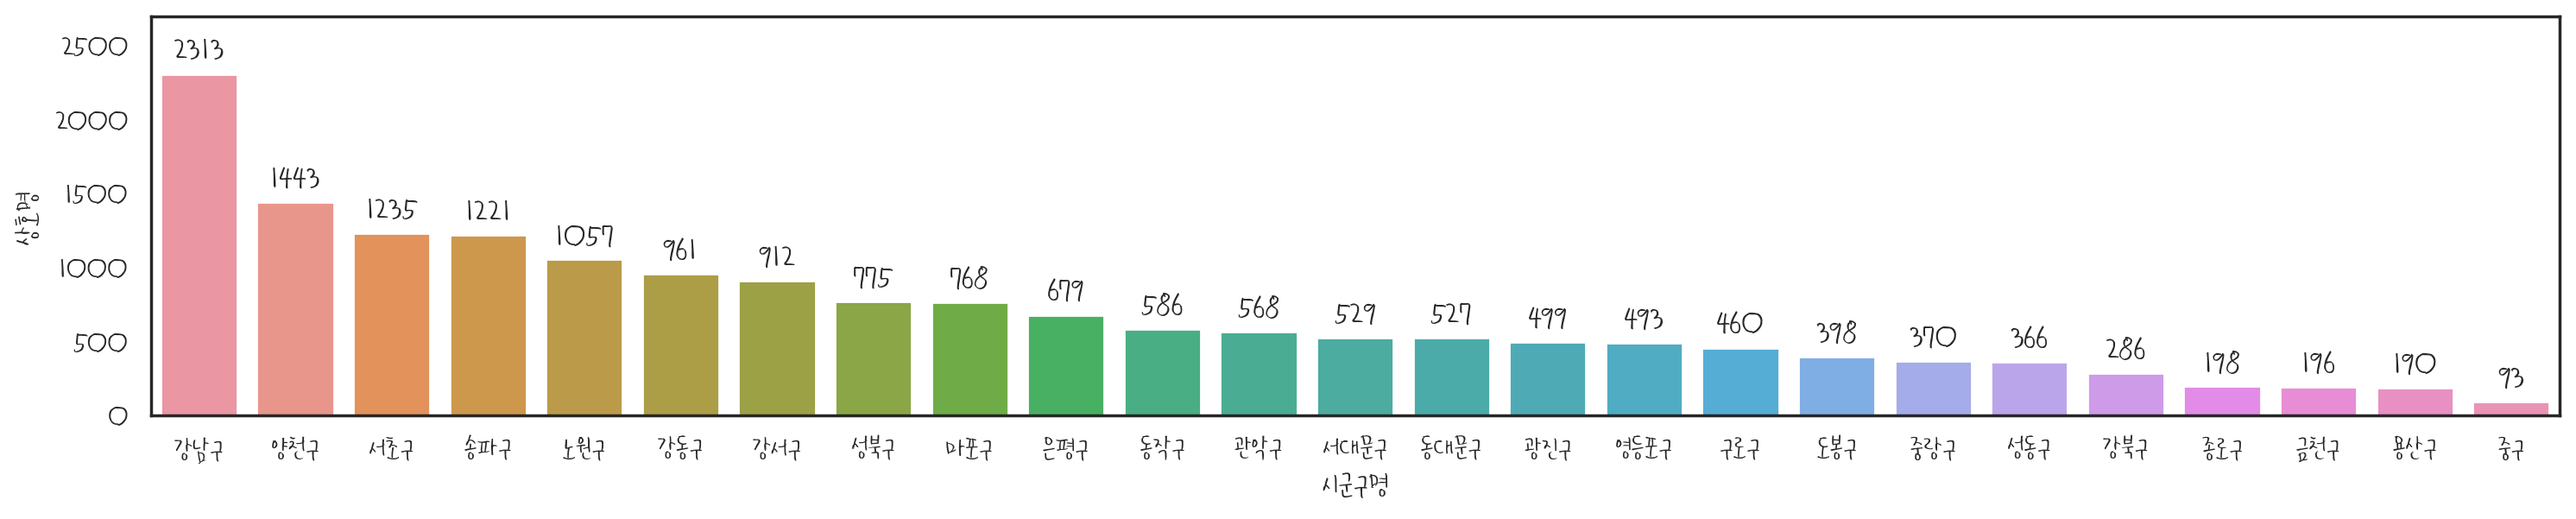

In [300]:
plt.figure(figsize=(18,3))
ax = sns.barplot(x=result.index, y=result)
labels = ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=12)
plt.ylim(0,2700)
plt.show()

# 14. 서울시 데이터의 경도와 위도를 산점도로 시각화
## ① df_academy의 경도와 위도를 시군구명별로 색상을 다르게하여 scatterplot으로 시각화


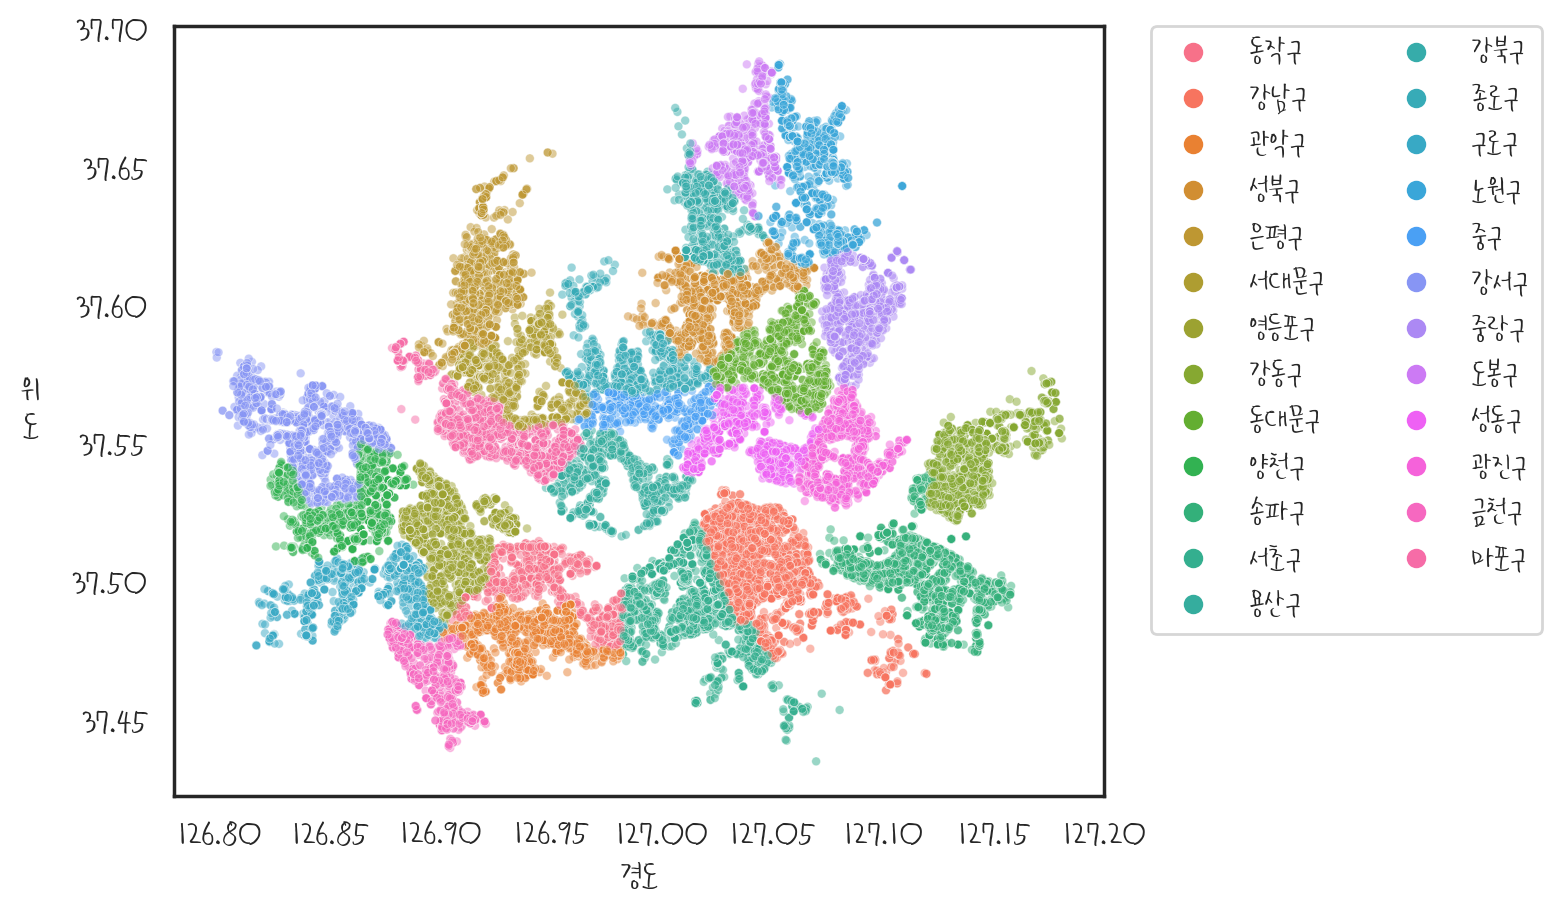

In [315]:
plt.figure(figsize=(6,5))

ax=sns.scatterplot(data=df_academy, x='경도', y='위도', hue='시군구명', s=10, alpha=0.5)

ax.set_ylabel('위\n도', rotation=0, labelpad=15, va='center')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용

## ② df_academy의 경도와 위도를 상권업종소분류명별로 색상을 다르게하여 scatterplot으로 시각화

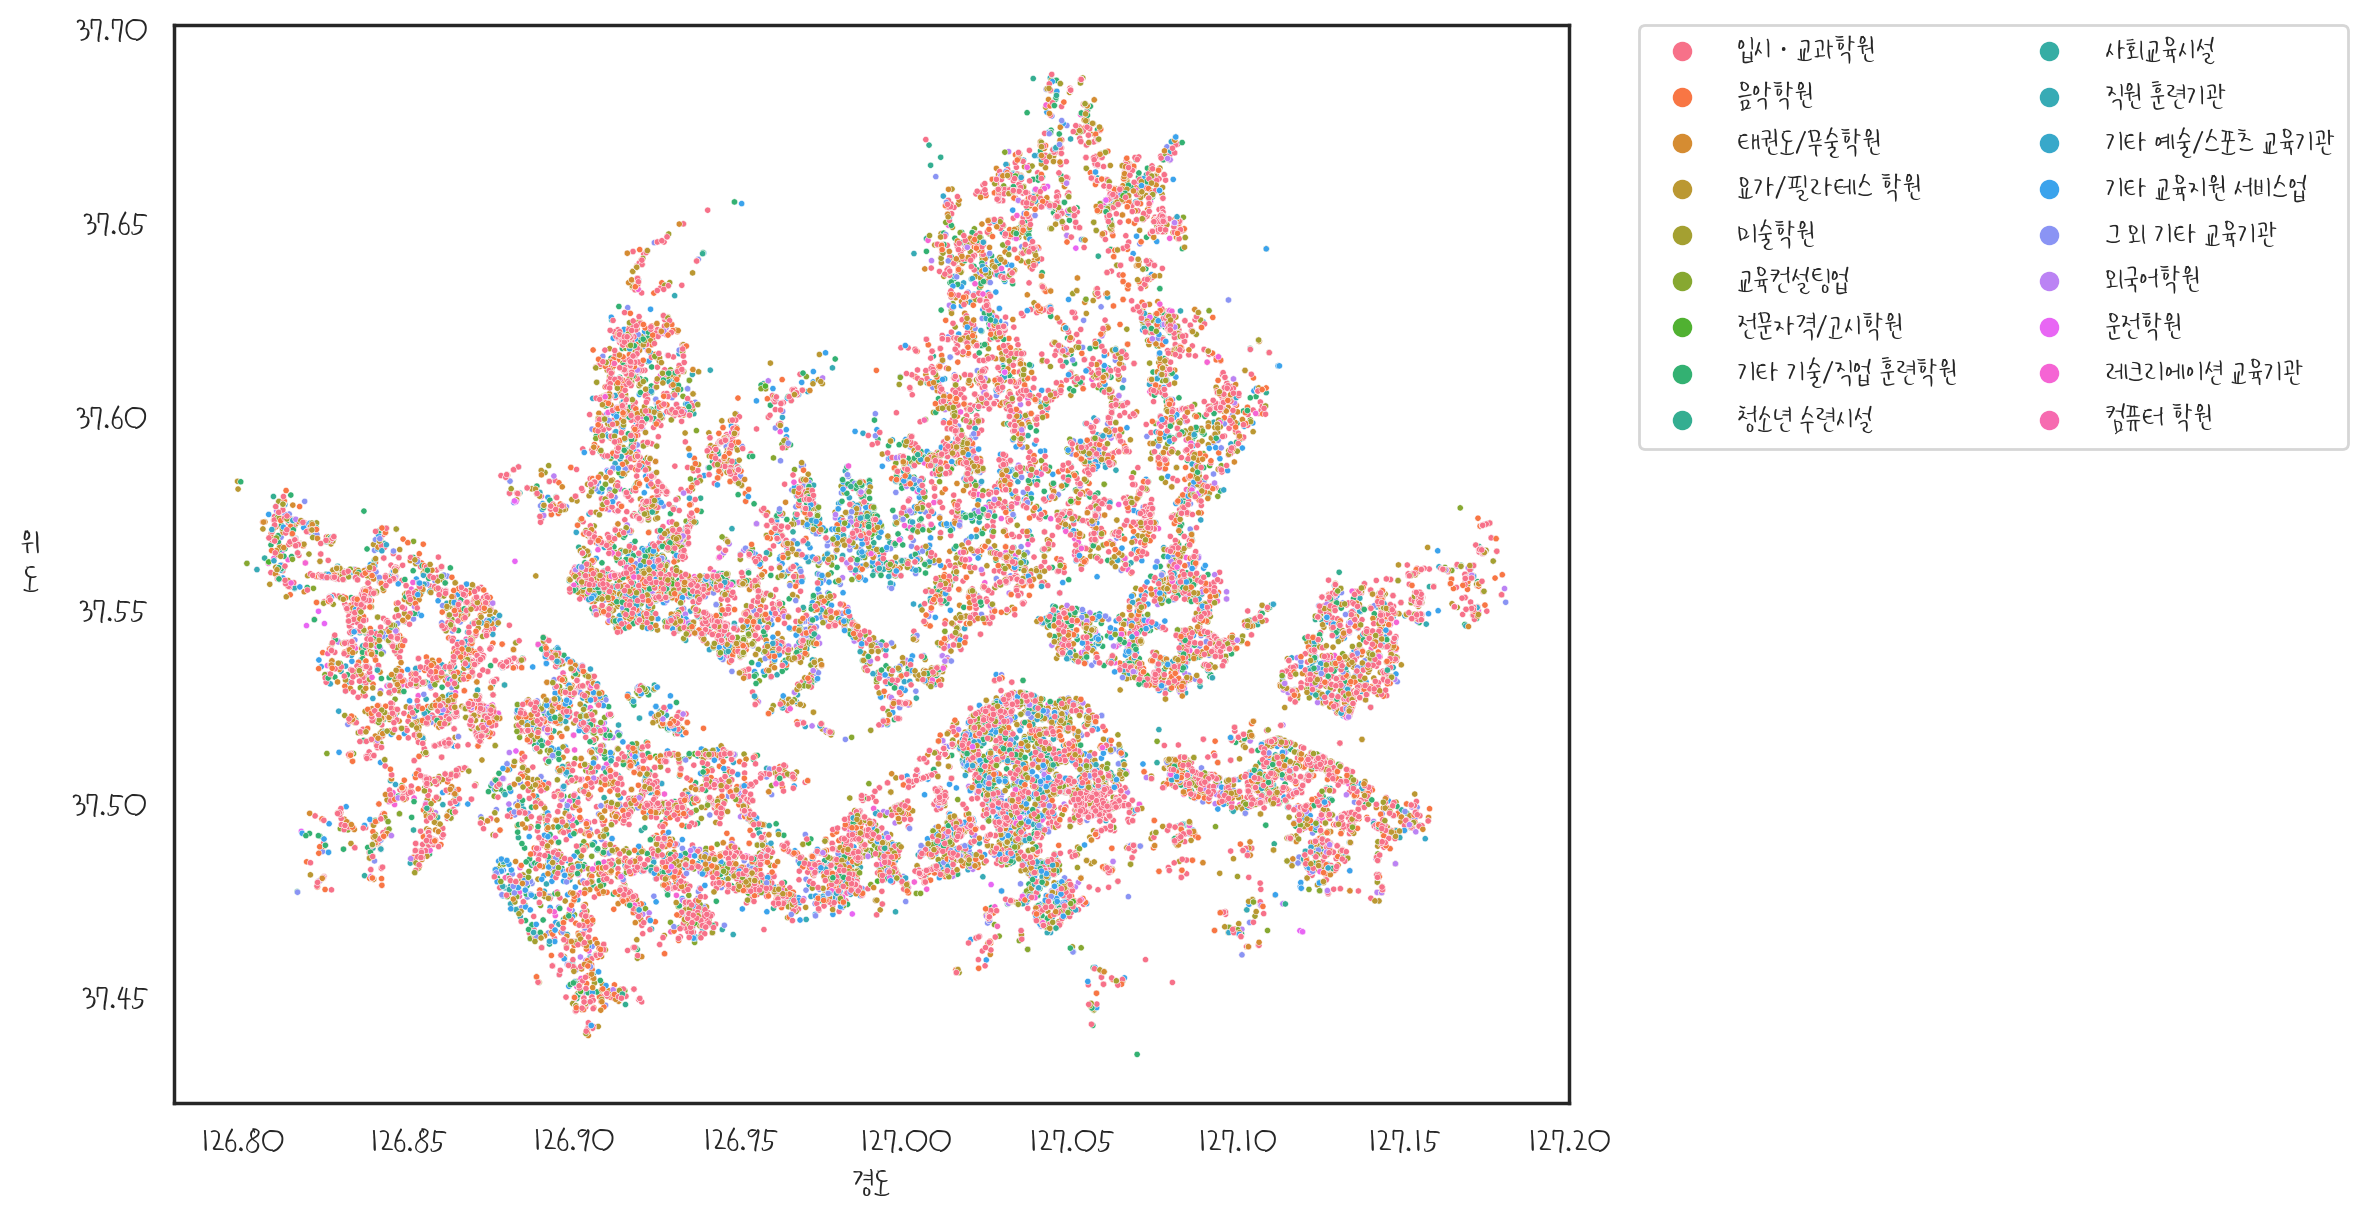

In [321]:
plt.figure(figsize=(9,7))

ax=sns.scatterplot(data=df_academy, x='경도', y='위도', hue='상권업종소분류명', s=5)

ax.set_ylabel('위\n도', rotation=0, labelpad=15, va='center')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

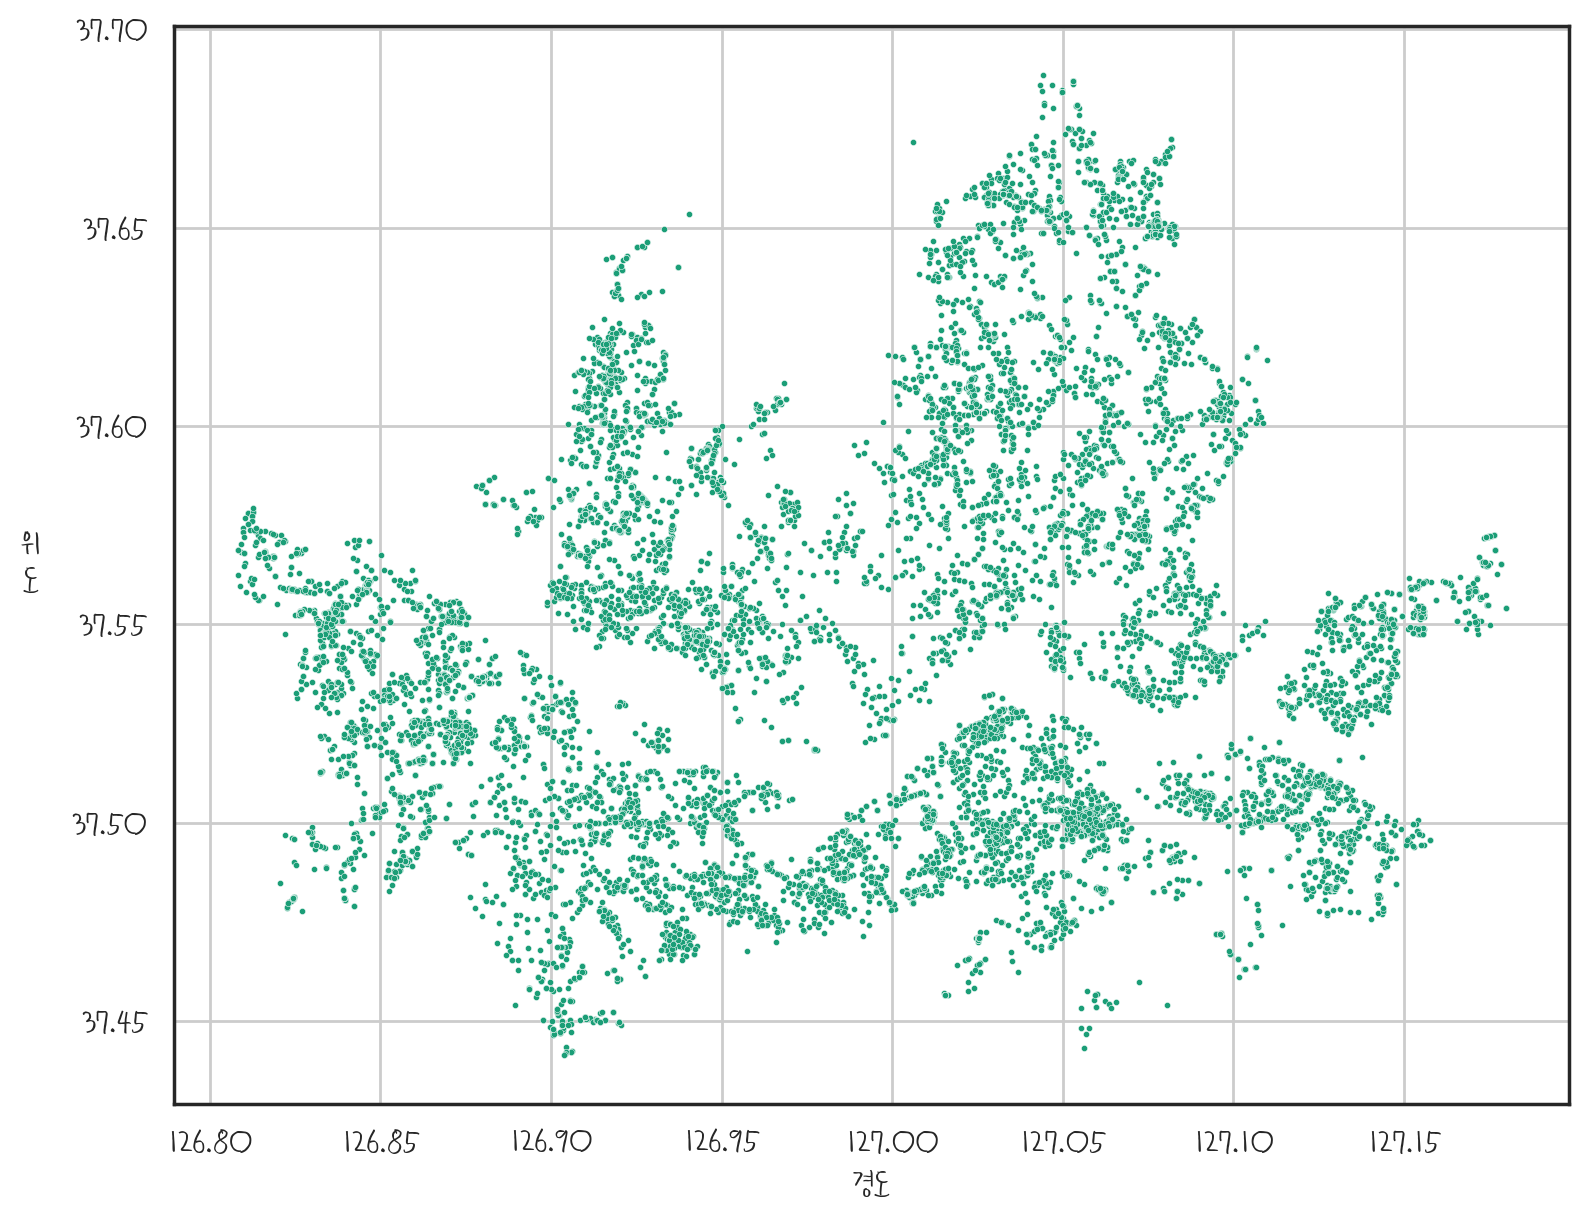

In [332]:
plt.figure(figsize=(9,7))

ax=sns.scatterplot(data=df_academy[df_academy['상권업종소분류명']=='입시·교과학원'], x='경도', y='위도', s=5)

plt.grid(axis='x')
plt.grid(axis='y')

ax.set_ylabel('위\n도', rotation=0, labelpad=15, va='center')

plt.show()

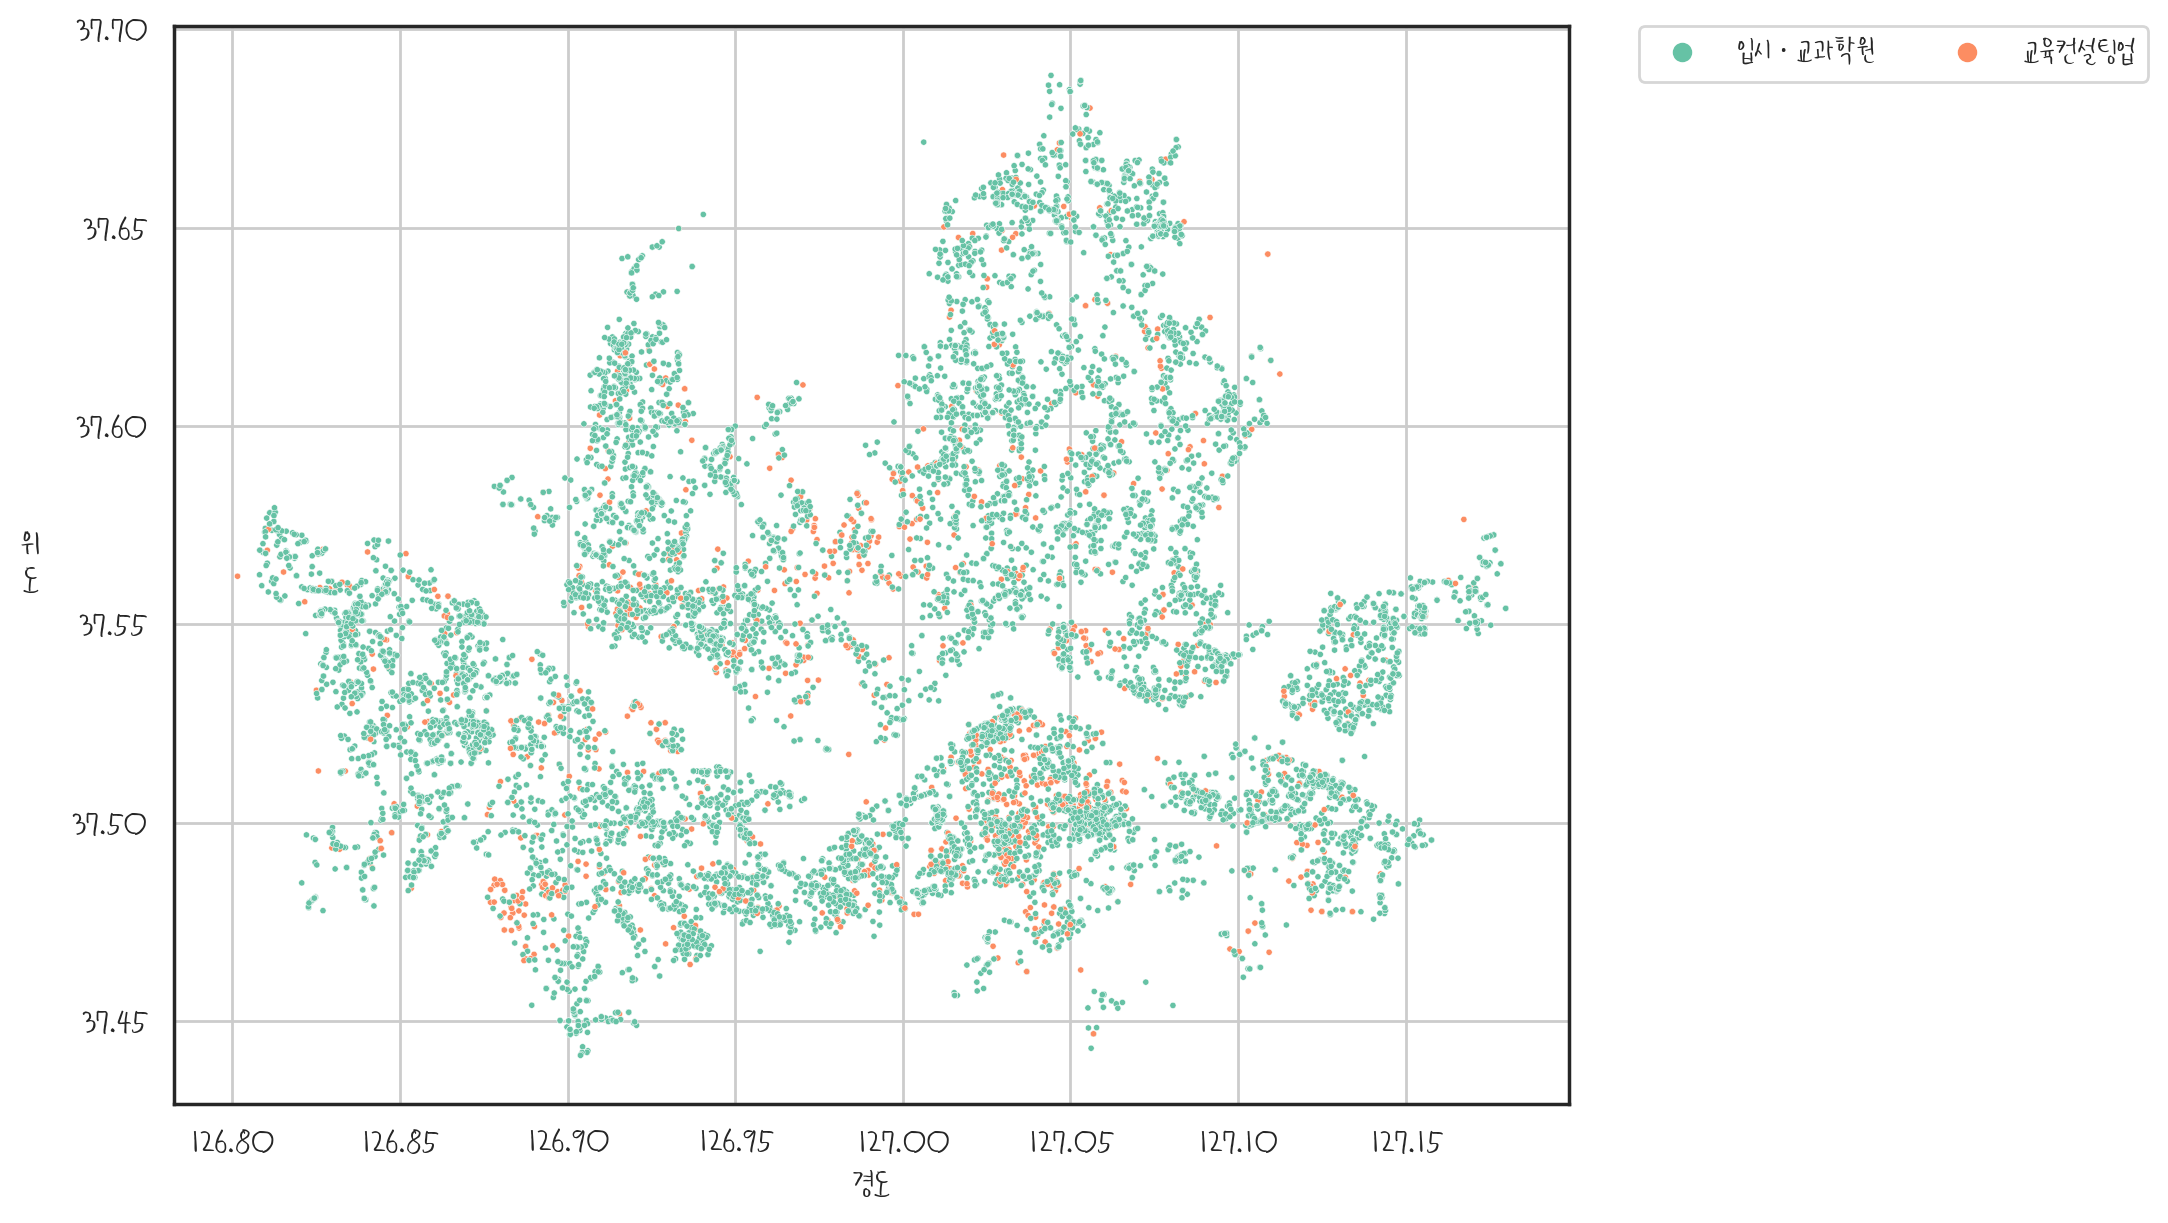

In [329]:
plt.figure(figsize=(9,7))

ax=sns.scatterplot(data=df_academy_sel, x='경도', y='위도', hue='상권업종소분류명', s=5, palette='Set2')

plt.grid(axis='x')
plt.grid(axis='y')

ax.set_ylabel('위\n도', rotation=0, labelpad=15, va='center')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

## ③ “입시·교과학원” 데이터만, 경도와 위도를 시군구명별로 색상을 다르게하여 scatterplot으로 시각화

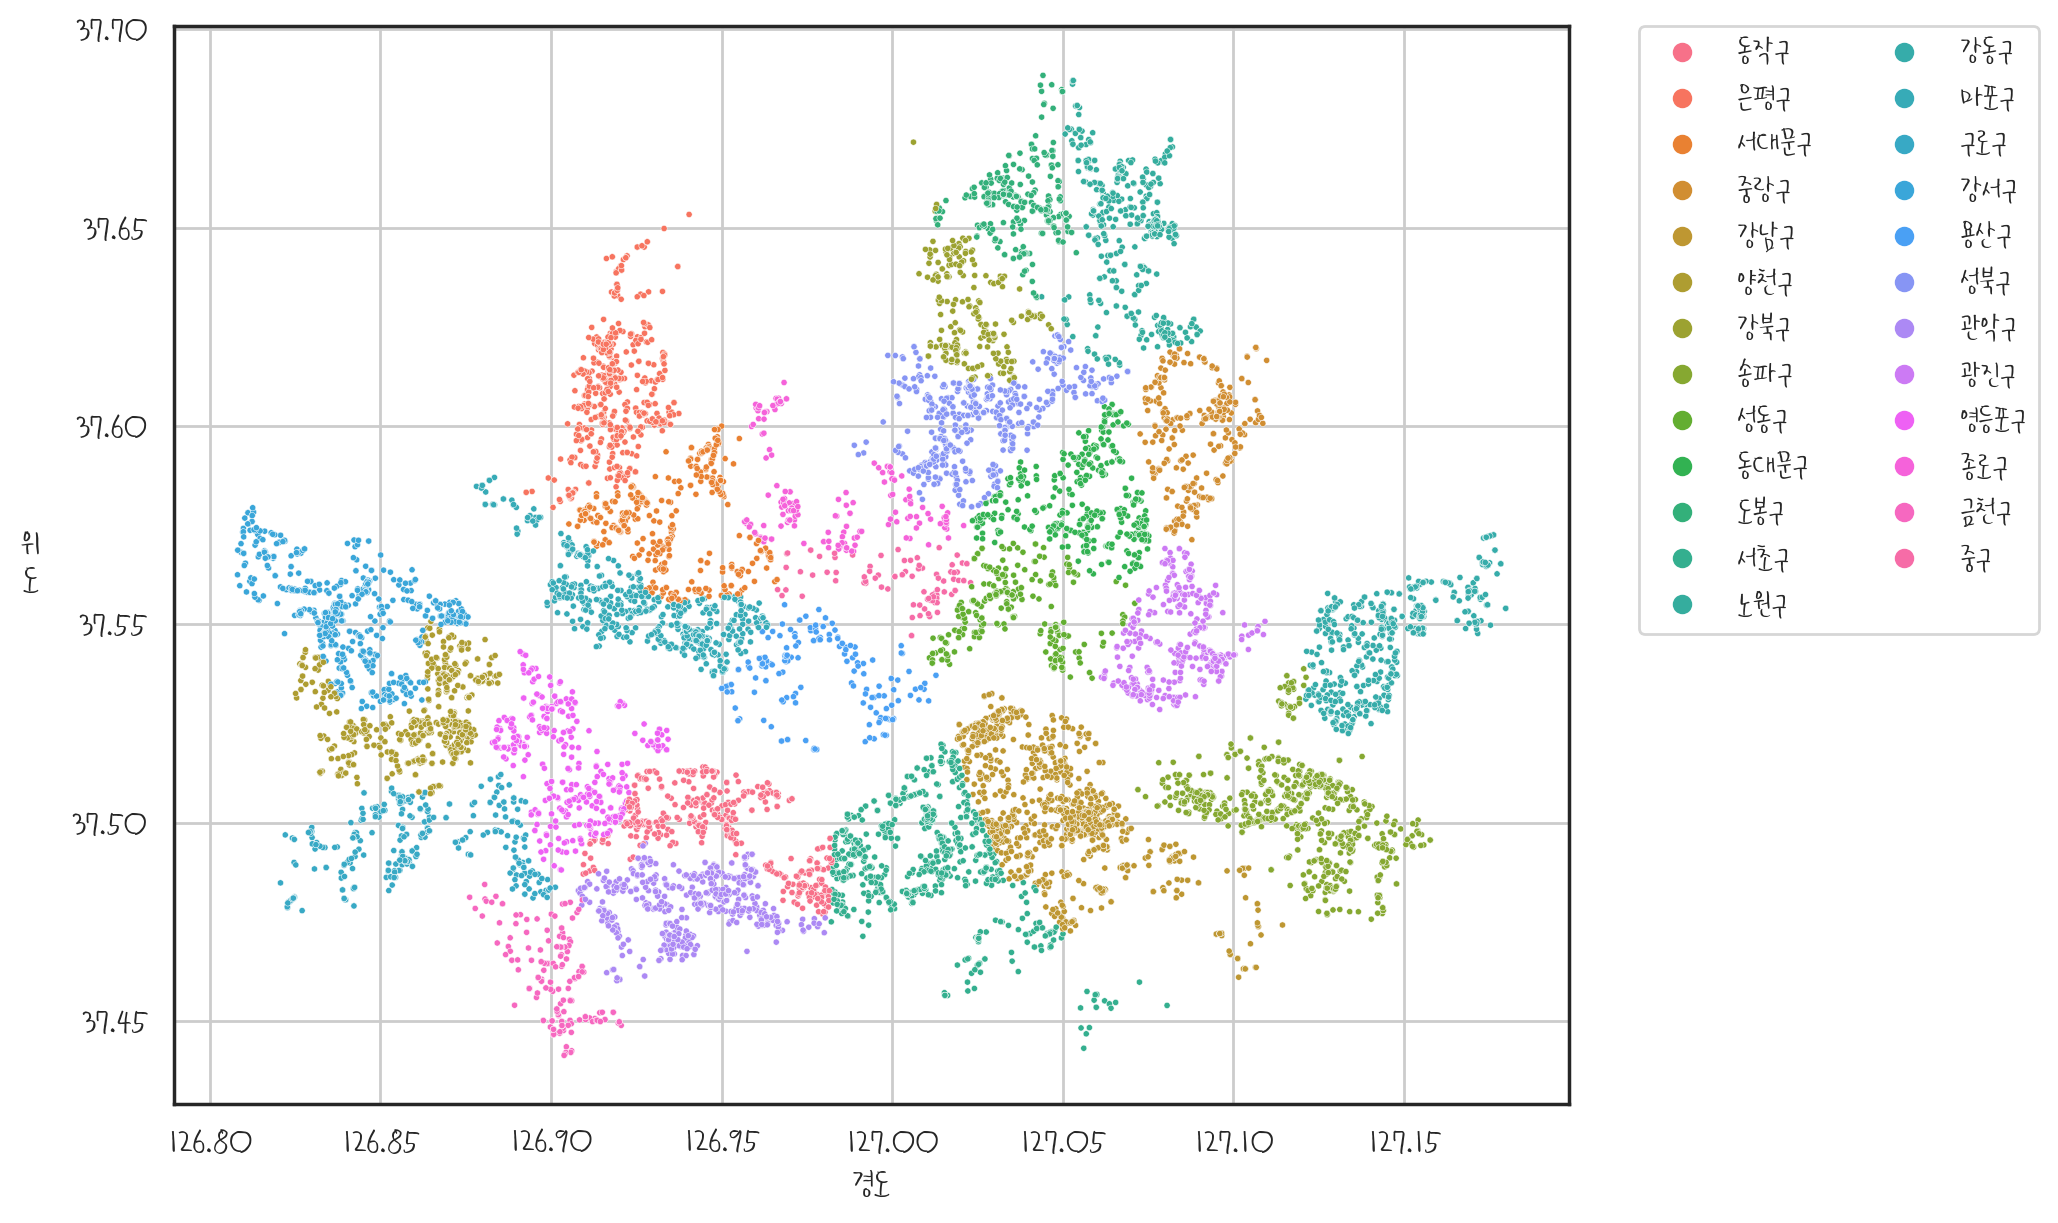

In [339]:
plt.figure(figsize=(9,7))

ax=sns.scatterplot(data=df_academy[df_academy['상권업종소분류명']=='입시·교과학원'], x='경도', y='위도', s=5, hue='시군구명')

plt.grid(axis='x')
plt.grid(axis='y')

ax.set_ylabel('위\n도', rotation=0, labelpad=15, va='center')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

## ④ “태권도/무술학원” 데이터만, 경도와 위도를 시군구명별로 색상을 다르게하여 scatterplot으로 시각화

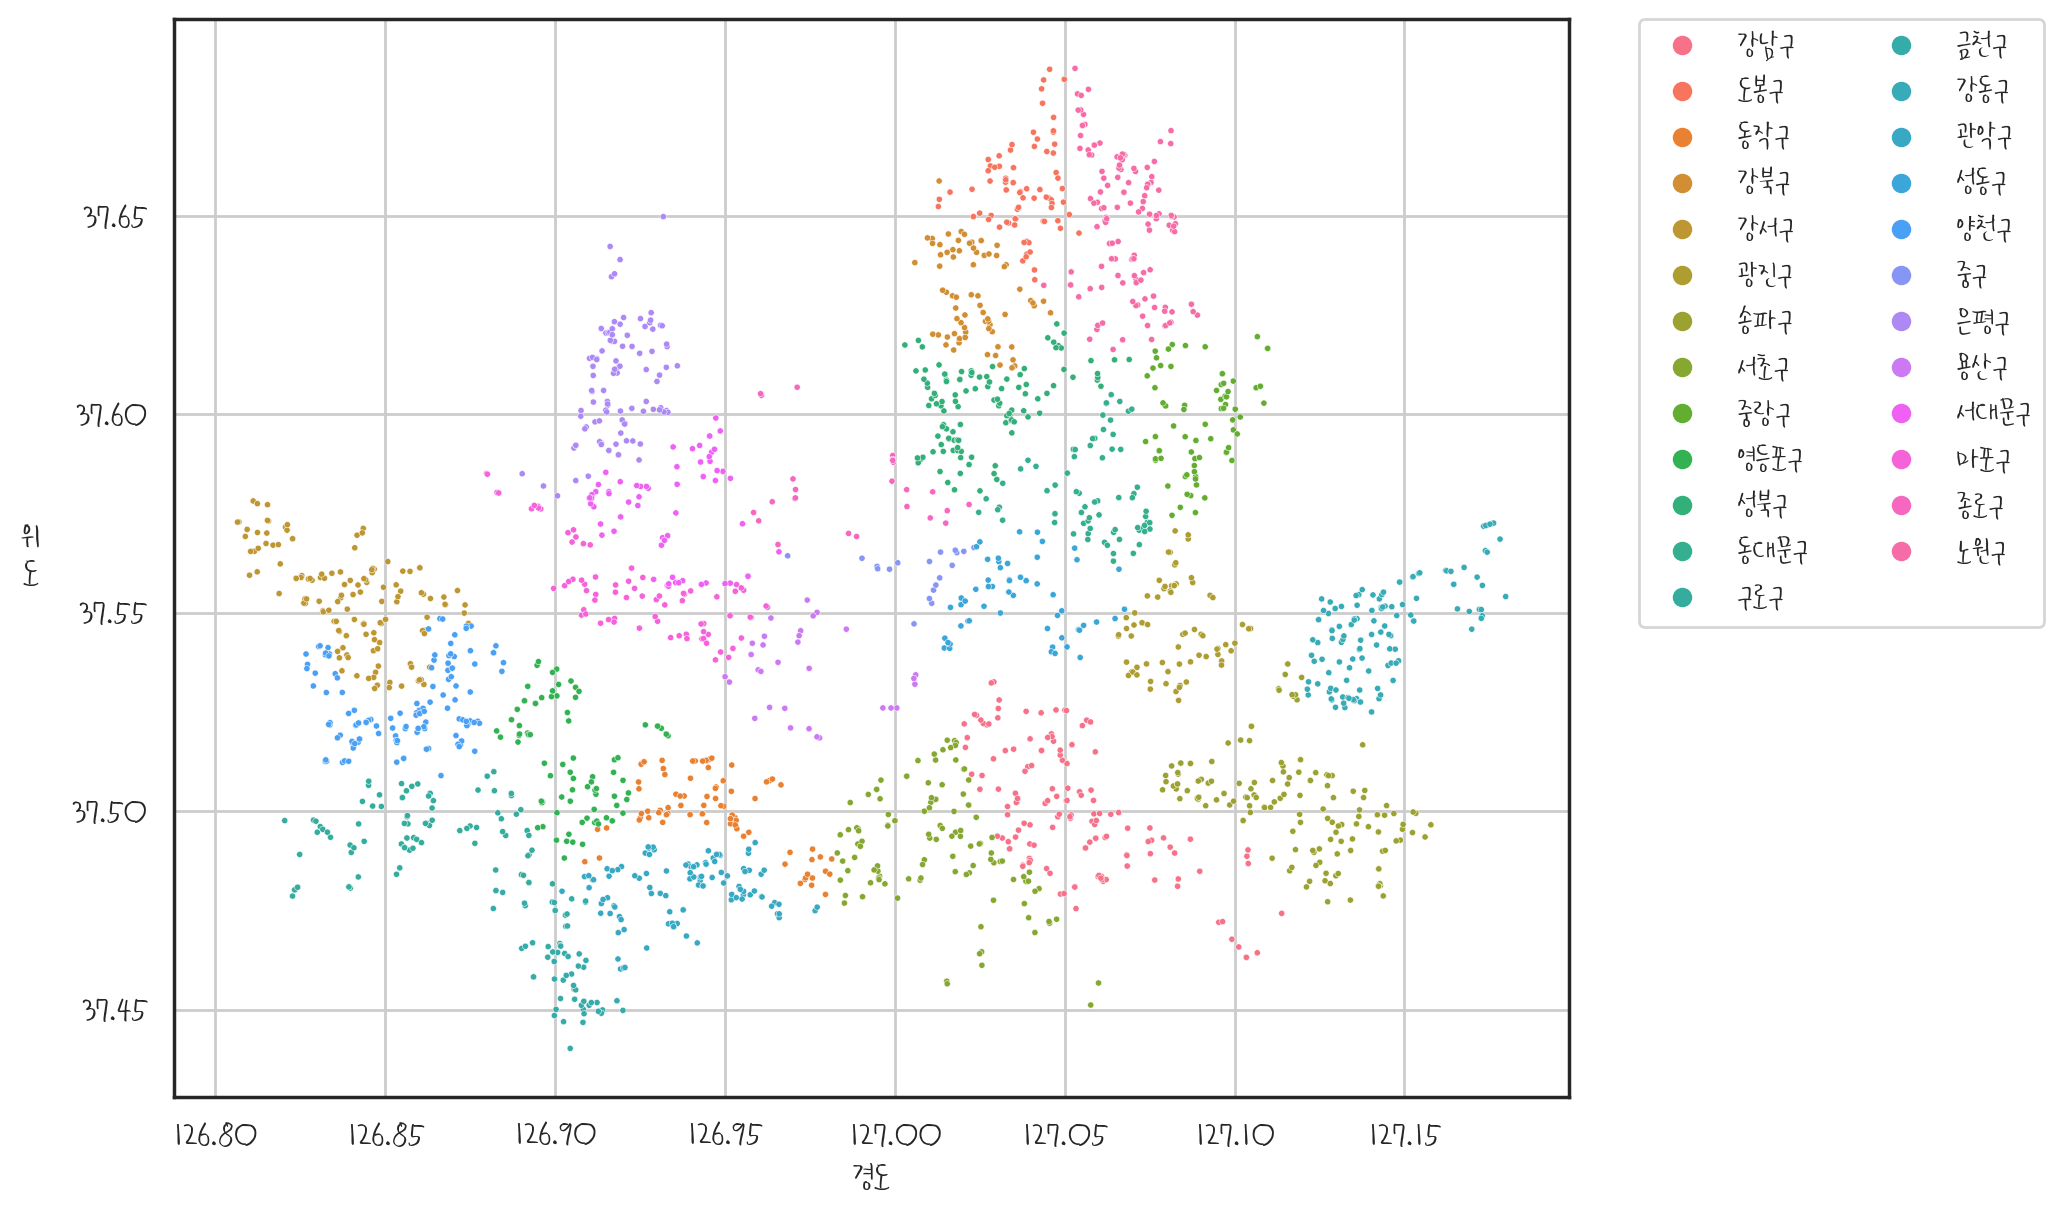

In [340]:
plt.figure(figsize=(9,7))

ax=sns.scatterplot(data=df_academy[df_academy['상권업종소분류명']=='태권도/무술학원'], x='경도', y='위도', s=5, hue='시군구명')

plt.grid(axis='x')
plt.grid(axis='y')

ax.set_ylabel('위\n도', rotation=0, labelpad=15, va='center')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

## ⑤ “입시·교과학원” 데이터와 “태권도/무술학원” 데이터의 경도와 위도를 상권업종소분류명별로 색상을 다르게하여 scatterplot으로 시각화

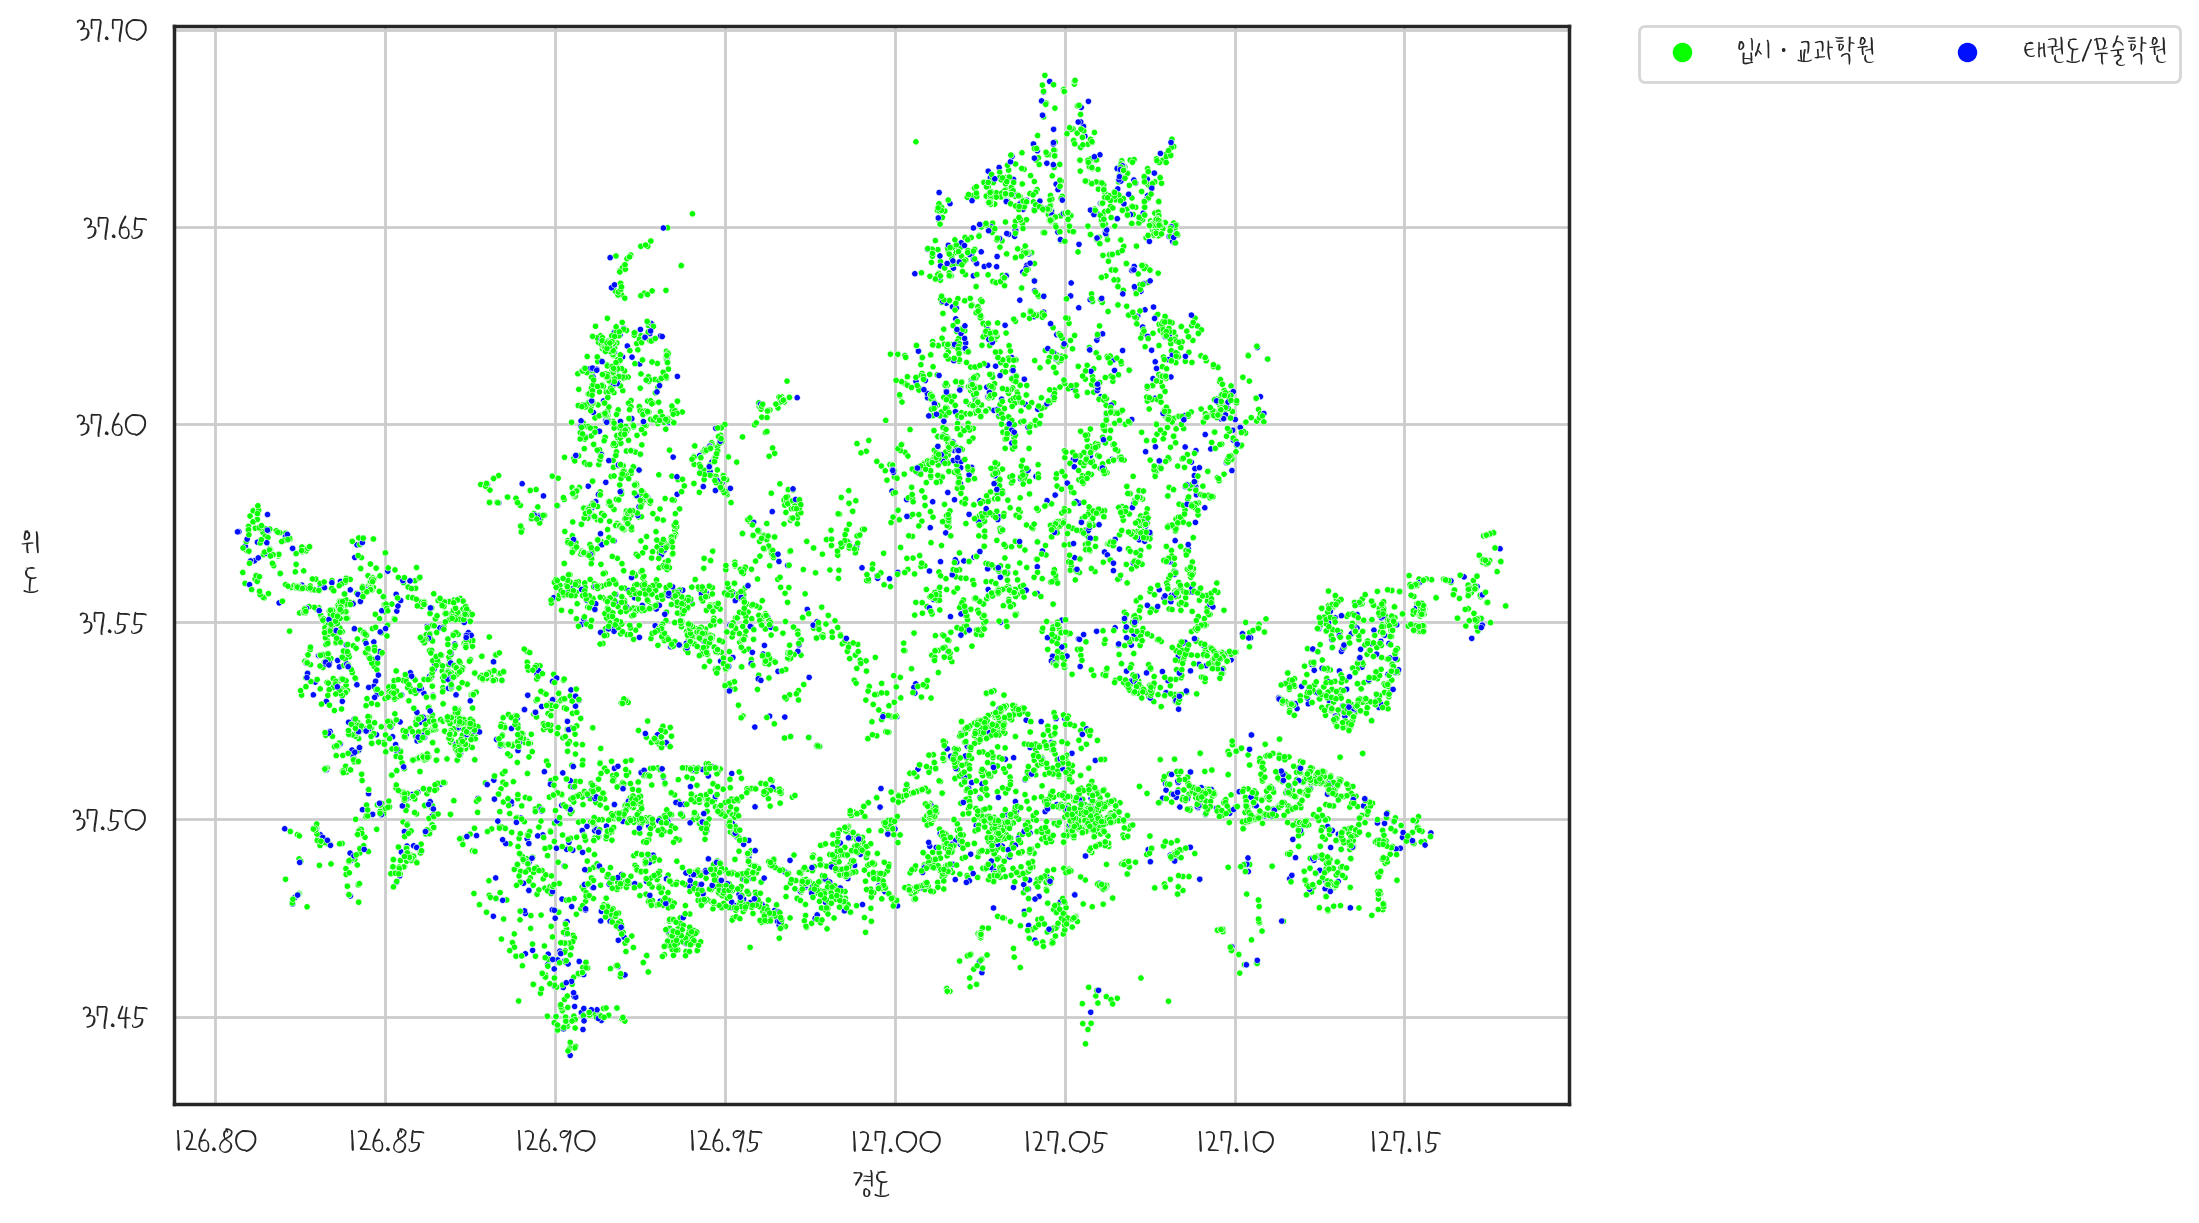

In [355]:
plt.figure(figsize=(9,7))

ax=sns.scatterplot(data=df_academy[df_academy['상권업종소분류명'].isin(['입시·교과학원','태권도/무술학원'])], x='경도', y='위도', s=5, hue='상권업종소분류명', palette='hsv')

plt.grid(axis='x')
plt.grid(axis='y')

ax.set_ylabel('위\n도', rotation=0, labelpad=15, va='center')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

# 15. 지도시각화 : Folium
` 아나콘다 프롬프트에서 아래의 둘 중 하나를 실행`

`pip install folium`

`conda install -c conda-forge folium`

-	docs : https://python-visualization.github.io/folium/latest/getting_started.html?utm_source=chatgpt.com
-	Quickstart : https://python-visualization.github.io/folium/version-v0.9.1/quickstart.html?utm_source=chatgpt.com


In [389]:
# import folium
# m = folium.Map(location=(37.4865,126.9295),
#               zoom_start=15,
#               width=800,
#               height=400)
# m

In [444]:
# 상권업종소분류명이 태권도/무술학원과 입시·교과학원인 데이터
part = ['입시·교과학원','태권도/무술학원']
df_m = df_academy[df_academy['상권업종소분류명'].isin(part)].sample(1000, random_state=3)
df_m.shape

(1000, 17)

In [425]:
df_m.head().index

Int64Index([497534, 400706, 495063, 472056, 448702], dtype='int64')

In [411]:
import folium
lat_mean = df_m['위도'].mean()
long_mean = df_m['경도'].mean()

m = folium.Map(location=(lat_mean,long_mean),
              zoom_start=12,
              width=800,
              height=400)
m

* 지도에 마커 추가하기

In [427]:
display(df_m.loc[497534, ['상호명','도로명','위도','경도']])
display(df_m.loc[400706, ['상호명','도로명','위도','경도']])

상호명       리딩오션강동독서논술교습소
도로명    서울특별시 강동구 성내로15길
위도            37.527806
경도           127.128551
Name: 497534, dtype: object

상호명             마운틴영어교습소
도로명    서울특별시 동작구 사당로23나길
위도             37.487698
경도            126.975543
Name: 400706, dtype: object

In [430]:
for i in df_m[:10].index:
    print(i) 

497534
400706
495063
472056
448702
530830
527596
339090
120194
519941


In [449]:
# m = folium.Map([lat_mean, long_mean], zoom_start=12)

# for i in df_m.index:
#     lat = df_m.loc[i,'위도']
#     long = df_m.loc[i,'경도']
#     tooltip = "<b>{} - {}</b>".format(df_m.loc[i,'상호명'],
#                                      df_m.loc[i,'도로명'][6:])
#     folium.CircleMarker(
#         radius=5,
#         location=[lat, long],
#         tooltip=tooltip,
#         color='#b265e6',
#         fill='#d2b0e8'
#     ).add_to(m)

# m

In [446]:
# 태권도/무술학원과 입시·교과학원을 분리해서 지도 시각화
df1 = df_m[df_m['상권업종소분류명']=='태권도/무술학원']
df2 = df_m[df_m['상권업종소분류명']=='입시·교과학원']

In [455]:
# m = folium.Map([lat_mean, long_mean], 
#                zoom_start=12)

# for i in df1.index:
#     lat = df_m.loc[i, '위도']
#     long = df_m.loc[i, '경도']
#     tooltip = '<b>{} - {}</b>'.format(df_m.loc[i, '상호명'],
#                                      df_m.loc[i, '도로명'][6:])
#     folium.Circle(
#         radius=10,
#         location=[lat, long],
#         tooltip=tooltip,
#         color='red',
#         fill=False,
#     ).add_to(m)
    
# for i in df2.index:
#     lat = df_m.loc[i, '위도']
#     long = df_m.loc[i, '경도']
#     tooltip = '<b>{} - {}</b>'.format(df_m.loc[i, '상호명'],
#                                      df_m.loc[i, '도로명'][6:])
#     folium.Circle(
#         radius=10,
#         location=[lat, long],
#         tooltip=tooltip,
#         color='blue',
#         fill=False,
#     ).add_to(m)
# m

In [454]:
m.save('ch13.html')